In [136]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import norm
import matplotlib
os.environ["XLA_FLAGS"] = "--xla_cpu_use_thunk_runtime=false"
import jax.numpy as jnp
from jax import config, random
import numpyro, jax
import numpyro.distributions as dist

from jnkepler.jaxttv import JaxTTV
from jnkepler.jaxttv import ttv_default_parameter_bounds, ttv_optim_curve_fit, scale_pdic
import corner
import pickle
import dill
import os
import pandas as pd

In [137]:
TESS_offset = 2457000

# Load data

In [154]:
# file_name = '1339_jnkep_initial_fit_data.pkl'
# file_name = '1339_jnkep_initial_fit_data_hessian_tree-11_accept-90_emax-0.5.pkl'
# file_name = '1339_jnkep_initial_fit_data_hessian_tree-11_accept-95_emax-0.5_RV.pkl'

# file_name= '1339_jnkep_initial_fit_data_hessian_tree-11_accept-95_emax-0.5.pkl'
# file_name = 'mcmc_runs/1339_jnkep_initial_fit_data_hessian_tree-11_accept-95_emax-0.5_infl_err6.pkl'
file_name = '1339_jnkep_initial_fit_photodyn_tree11_jitter.pkl'
with open(file_name, 'rb') as f:
    data = pickle.load(f)


nt = data['nt'] 
popt_transit = data['popt_transit']
popt_full = data['popt_full']
param_bounds_ttv = data['param_bounds']
param_bounds_transit = data['param_bounds_transit']
keys_ttv = data['keys_ttv']
keys_transit = data['keys_transit']

# popt = data['popt']
# param_bounds = data['param_bounds']
# jttv = data['jttv']

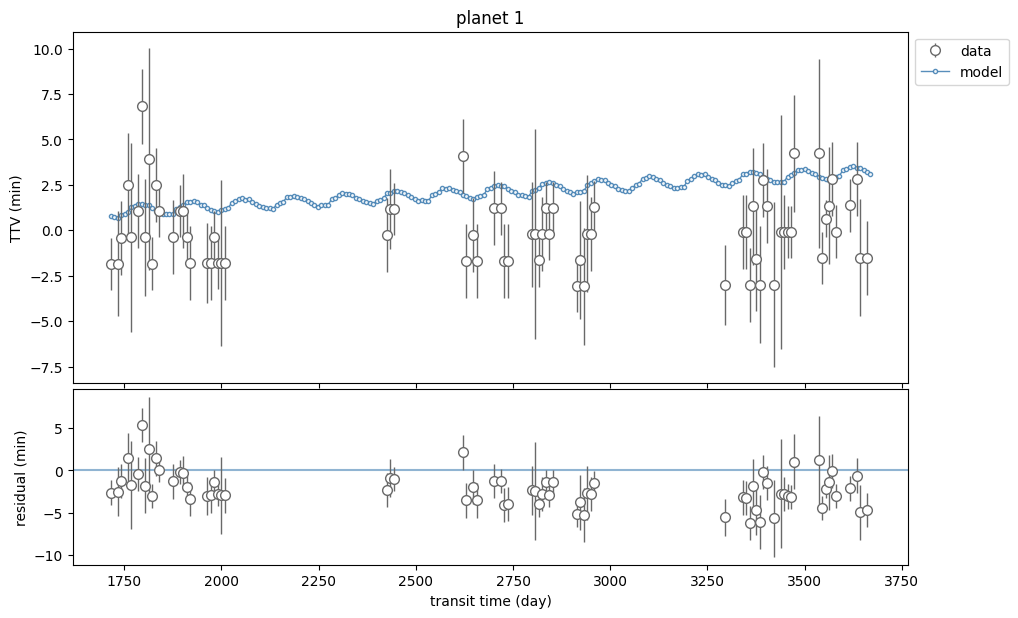

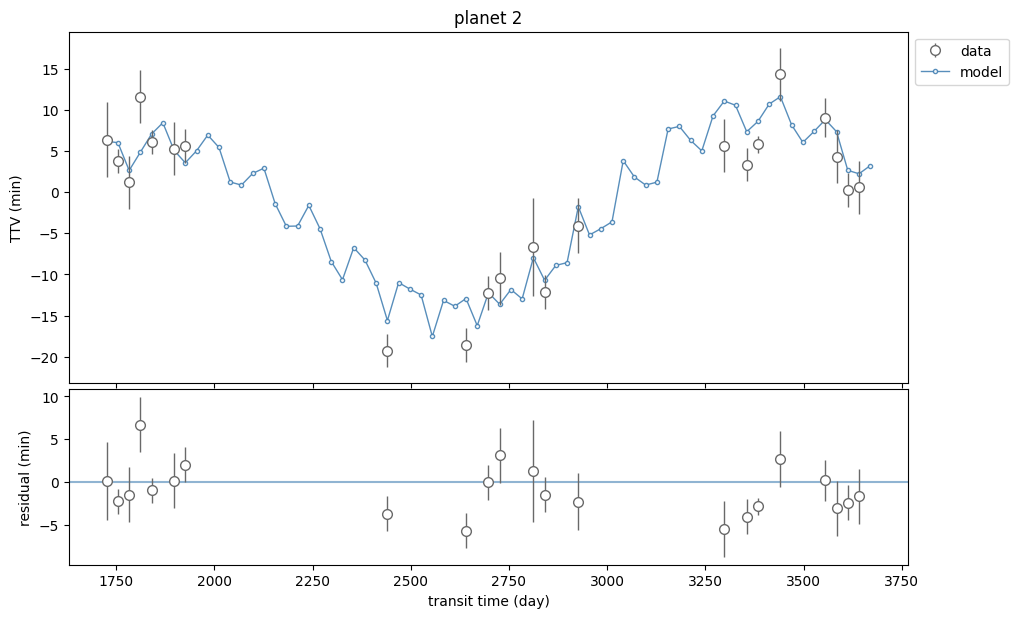

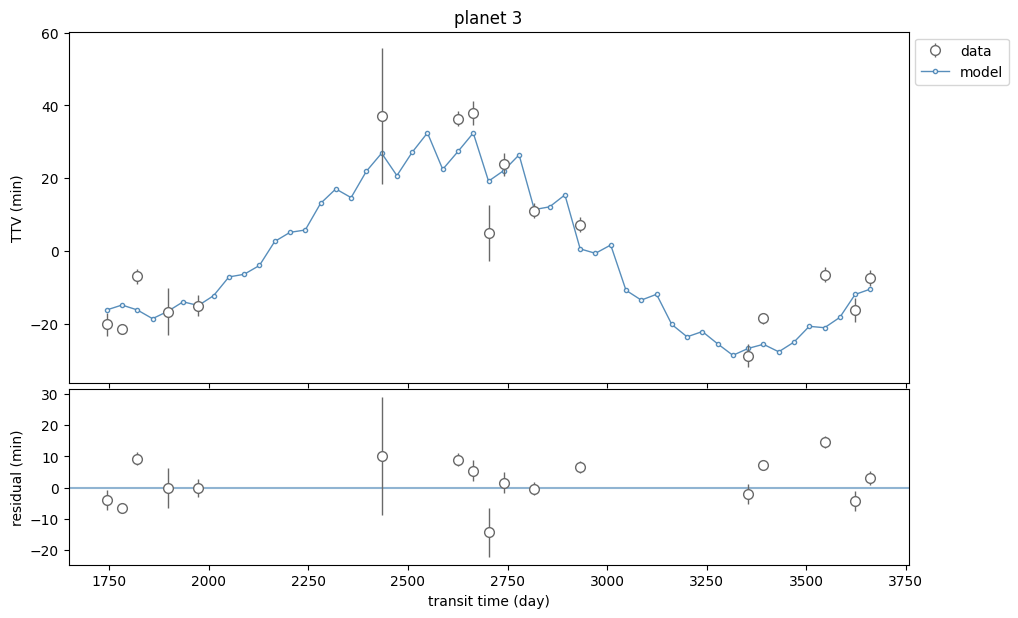

In [224]:
### Plot full fit 
tcall = nt.get_transit_times_all_list(popt_full, truncate=False)
nt.plot_model(tcall, marker='.')
plt.show()

In [155]:

# file_name = '1339_jnkep_fit_1339-2000burn-4000step.pkl'
# file_name = '1339_jnkep_fit_1339-2000burn-2000step-emax0.5.pkl'
# file_name = '1339_jnkep_nburn-1000_nsteps-1000_hessian_tree-11_accept-90_emax-0.5.pkl'
#file_name = '1339_jnkep_nburn-1000_nsteps-1000_hessian_tree-11_accept-95_emax-0.5_RV.pkl'
# file_name = "1339_jnkep_fit_fullls.pkl"

# file_name = '1339_jnkep_nburn-1000_nsteps-1000_hessian_tree-11_accept-95_emax-0.5.pkl'
file_name = 'mcmc_runs/1339_jnkep_nburn-1000_nsteps-1000_hessian_tree-11_accept-95_emax-0.5_infl_err6.pkl'
file_name = 'toi1339_photodynamics_1000burn_1000step_tree11_jitter.pkl'

working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")

file_path = os.path.join(data_dir, file_name)

In [156]:
with open(file_name, "rb") as f:
    mcmc = dill.load(f)
mcmc.print_summary()



                            mean       std    median      5.0%     95.0%     n_eff     r_hat
                  b[0]      0.65      0.04      0.66      0.59      0.72    383.63      1.02
                  b[1]      0.64      0.04      0.64      0.58      0.69    315.74      1.01
                  b[2]      0.48      0.06      0.49      0.40      0.58    334.71      1.02
       ecosw_scaled[0]      0.64      0.10      0.65      0.47      0.79    162.42      1.02
       ecosw_scaled[1]      0.44      0.11      0.50      0.23      0.57     70.74      1.05
       ecosw_scaled[2]      0.45      0.09      0.50      0.25      0.54     71.40      1.05
       esinw_scaled[0]      0.47      0.09      0.48      0.34      0.60    296.79      1.02
       esinw_scaled[1]      0.52      0.07      0.51      0.43      0.65    173.75      1.02
       esinw_scaled[2]      0.52      0.06      0.51      0.44      0.63    168.25      1.02
                   lna    -10.12      0.09    -10.12    -10.27     -9

In [157]:
# Posterior samples
posterior_samples = mcmc.get_samples()

# Shape of samples
print({k: v.shape for k, v in posterior_samples.items()})


{'b': (4000, 3), 'ecc': (4000, 3), 'ecosw': (4000, 3), 'ecosw_scaled': (4000, 3), 'esinw': (4000, 3), 'esinw_scaled': (4000, 3), 'fluxmodel': (4000, 6125), 'gppred': (4000, 6125), 'lna': (4000,), 'lnc': (4000,), 'lnjitter': (4000, 3), 'lnode': (4000, 2), 'meanflux': (4000,), 'meanflux_scaled': (4000,), 'normed_residual': (4000, 6125), 'period': (4000, 3), 'period_scaled': (4000, 3), 'pmass': (4000, 3), 'pmass_scaled': (4000, 3), 'q1': (4000,), 'q2': (4000,), 'radius_ratio': (4000, 3), 'radius_ratio_scaled': (4000, 3), 'residual': (4000, 6125), 'smass': (4000,), 'srad': (4000,), 'tcmodel': (4000, 111), 'tic': (4000, 3), 'tic_scaled': (4000, 3)}


# Plot models drawn from posteriors 

In [158]:
samples = mcmc.get_samples()

In [225]:
means, stds = nt.sample_means_and_stds(samples, truncate=False)

<Figure size 1920x1440 with 0 Axes>

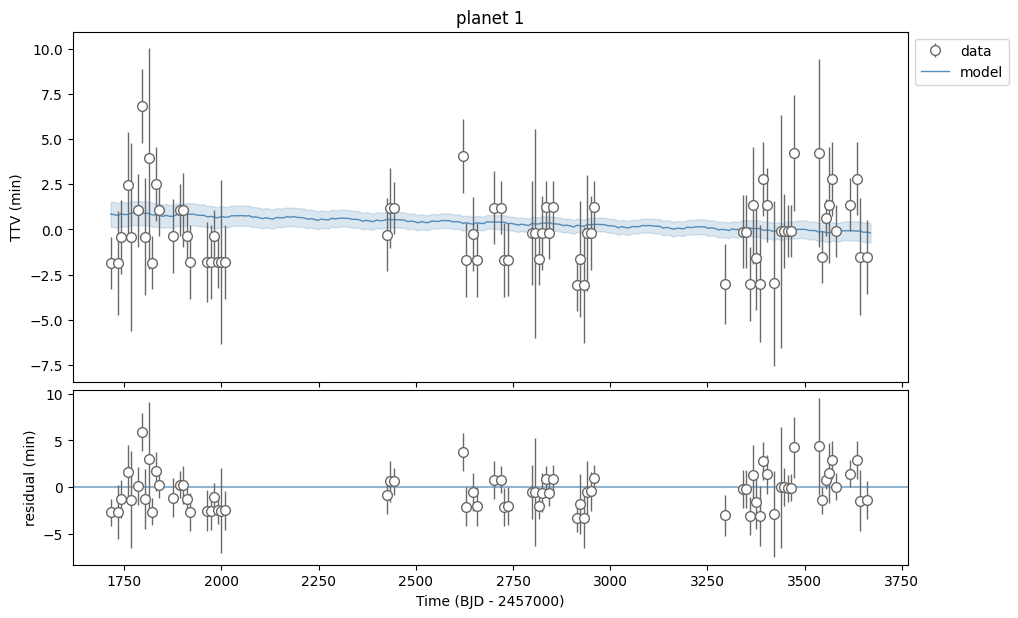

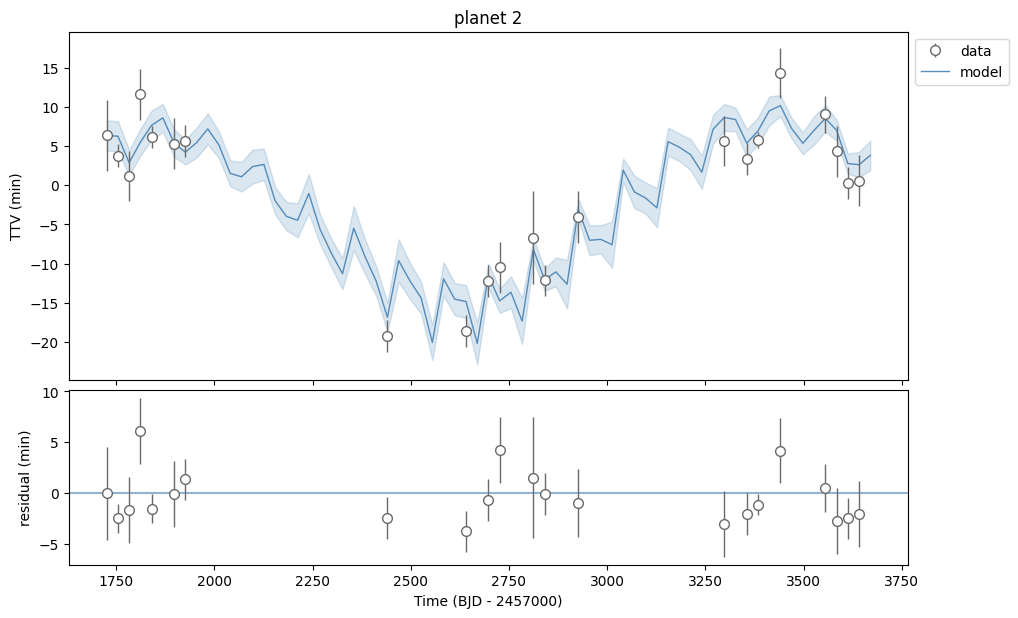

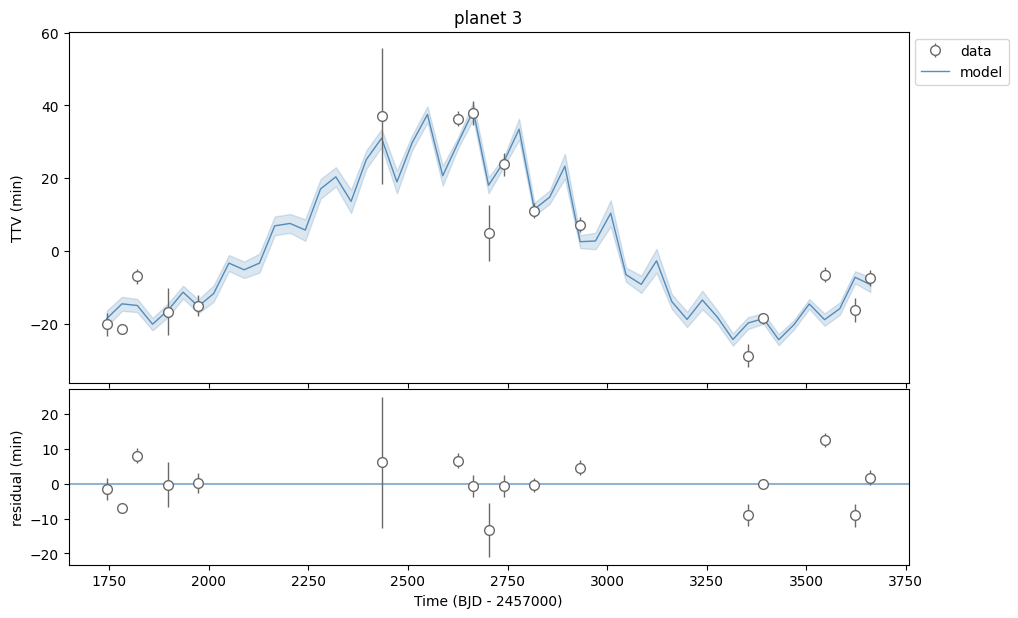

<Figure size 1920x1440 with 0 Axes>

In [226]:
nt.plot_model(means, tcmodelunclist=stds, xlabel=f'Time (BJD - {TESS_offset})')
plt.figure(dpi=300) 

# Trace and corner plots

In [161]:
sample_keys = ["ecosw", "esinw", "pmass", "period", "tic"] # uniform mass prior

In [162]:
import arviz as az
# idata = az.from_numpyro(mcmc)
samples_sorted = mcmc.get_samples(group_by_chain=True)
idata = az.from_dict(posterior=samples_sorted)

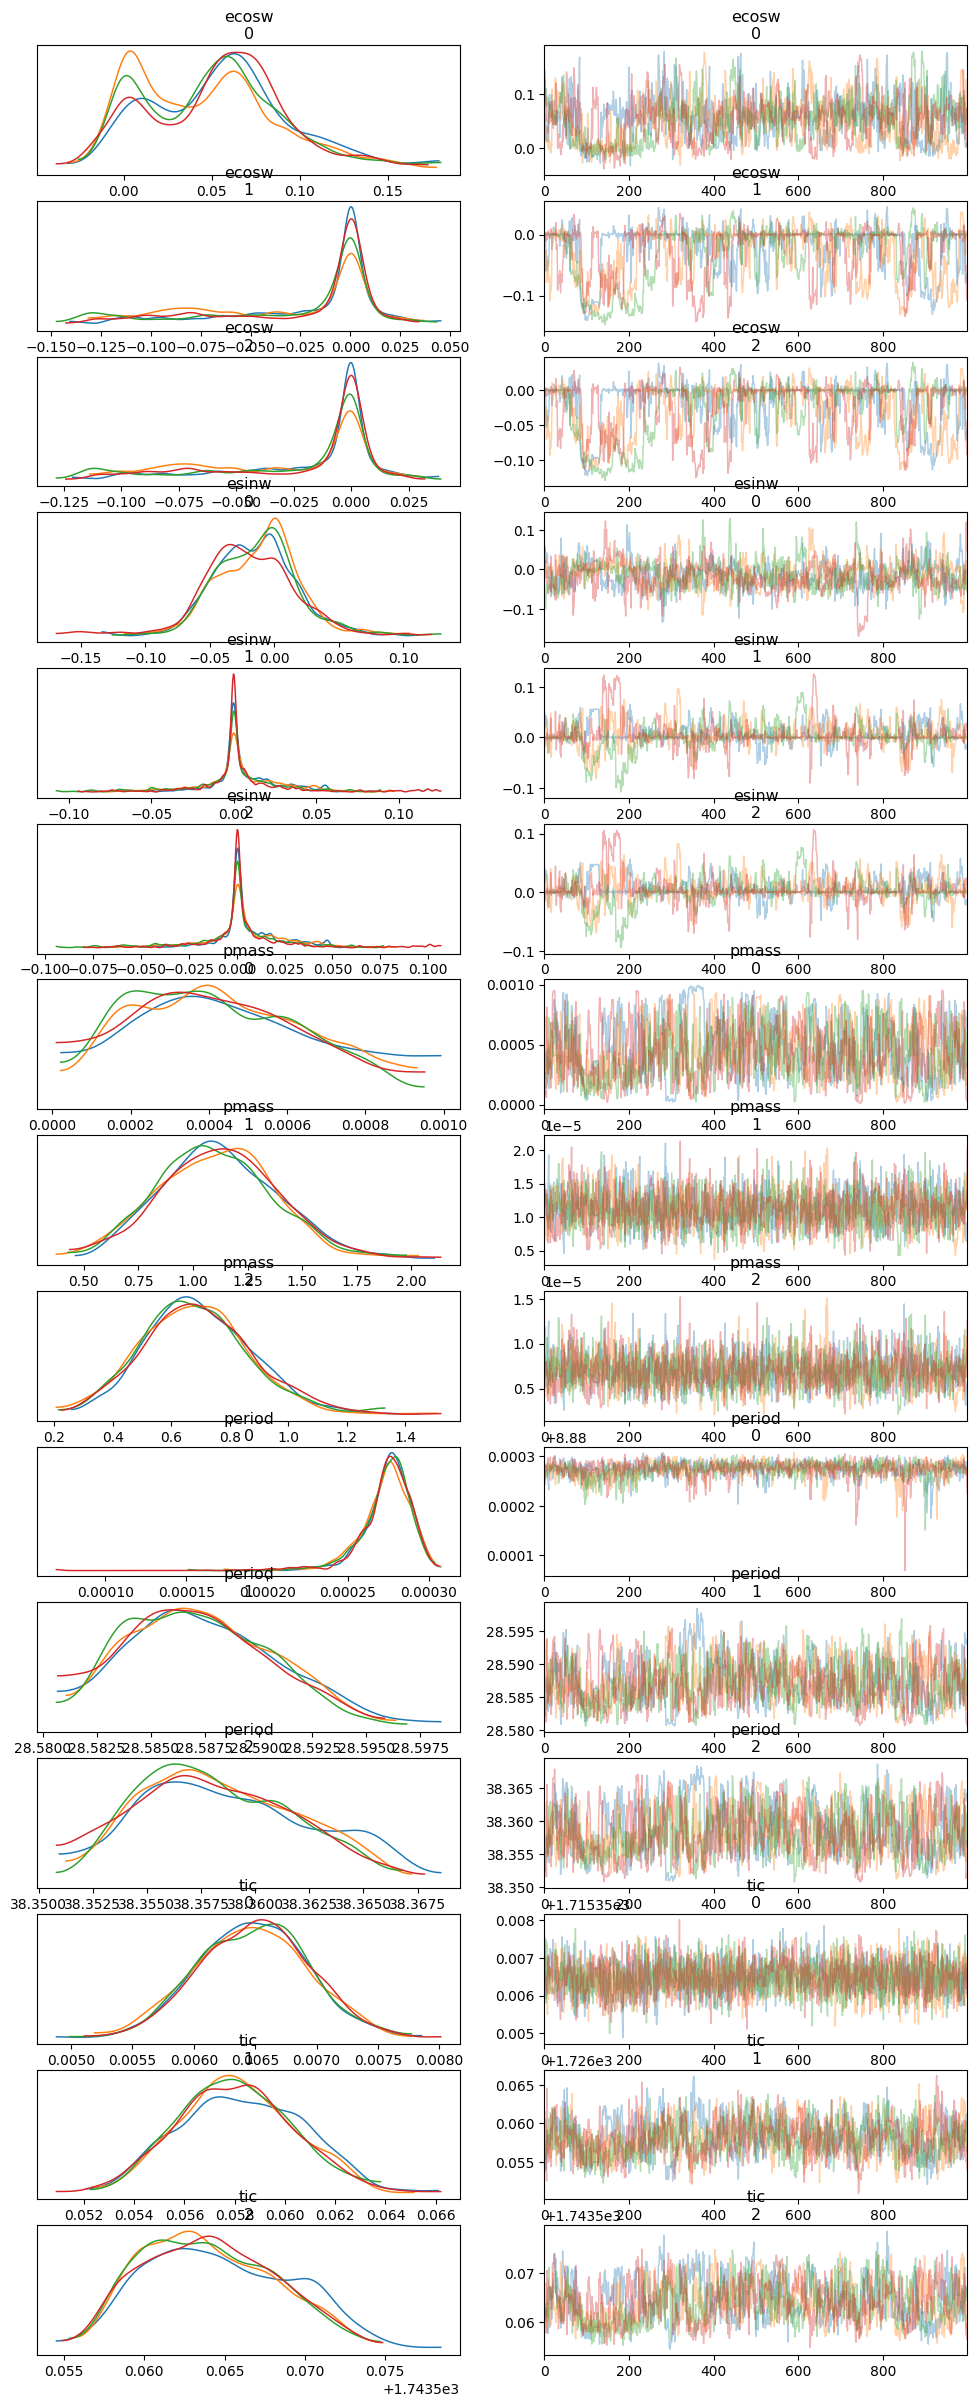

<Figure size 1920x1440 with 0 Axes>

In [163]:
# import arviz as az
# idata = az.from_numpyro(mcmc)
# fig = az.plot_trace(mcmc, var_names=sample_keys, compact=False)
fig = az.plot_trace(idata, var_names=sample_keys, compact=False)
plt.figure(dpi=300) 
plt.tight_layout(pad=0.2)

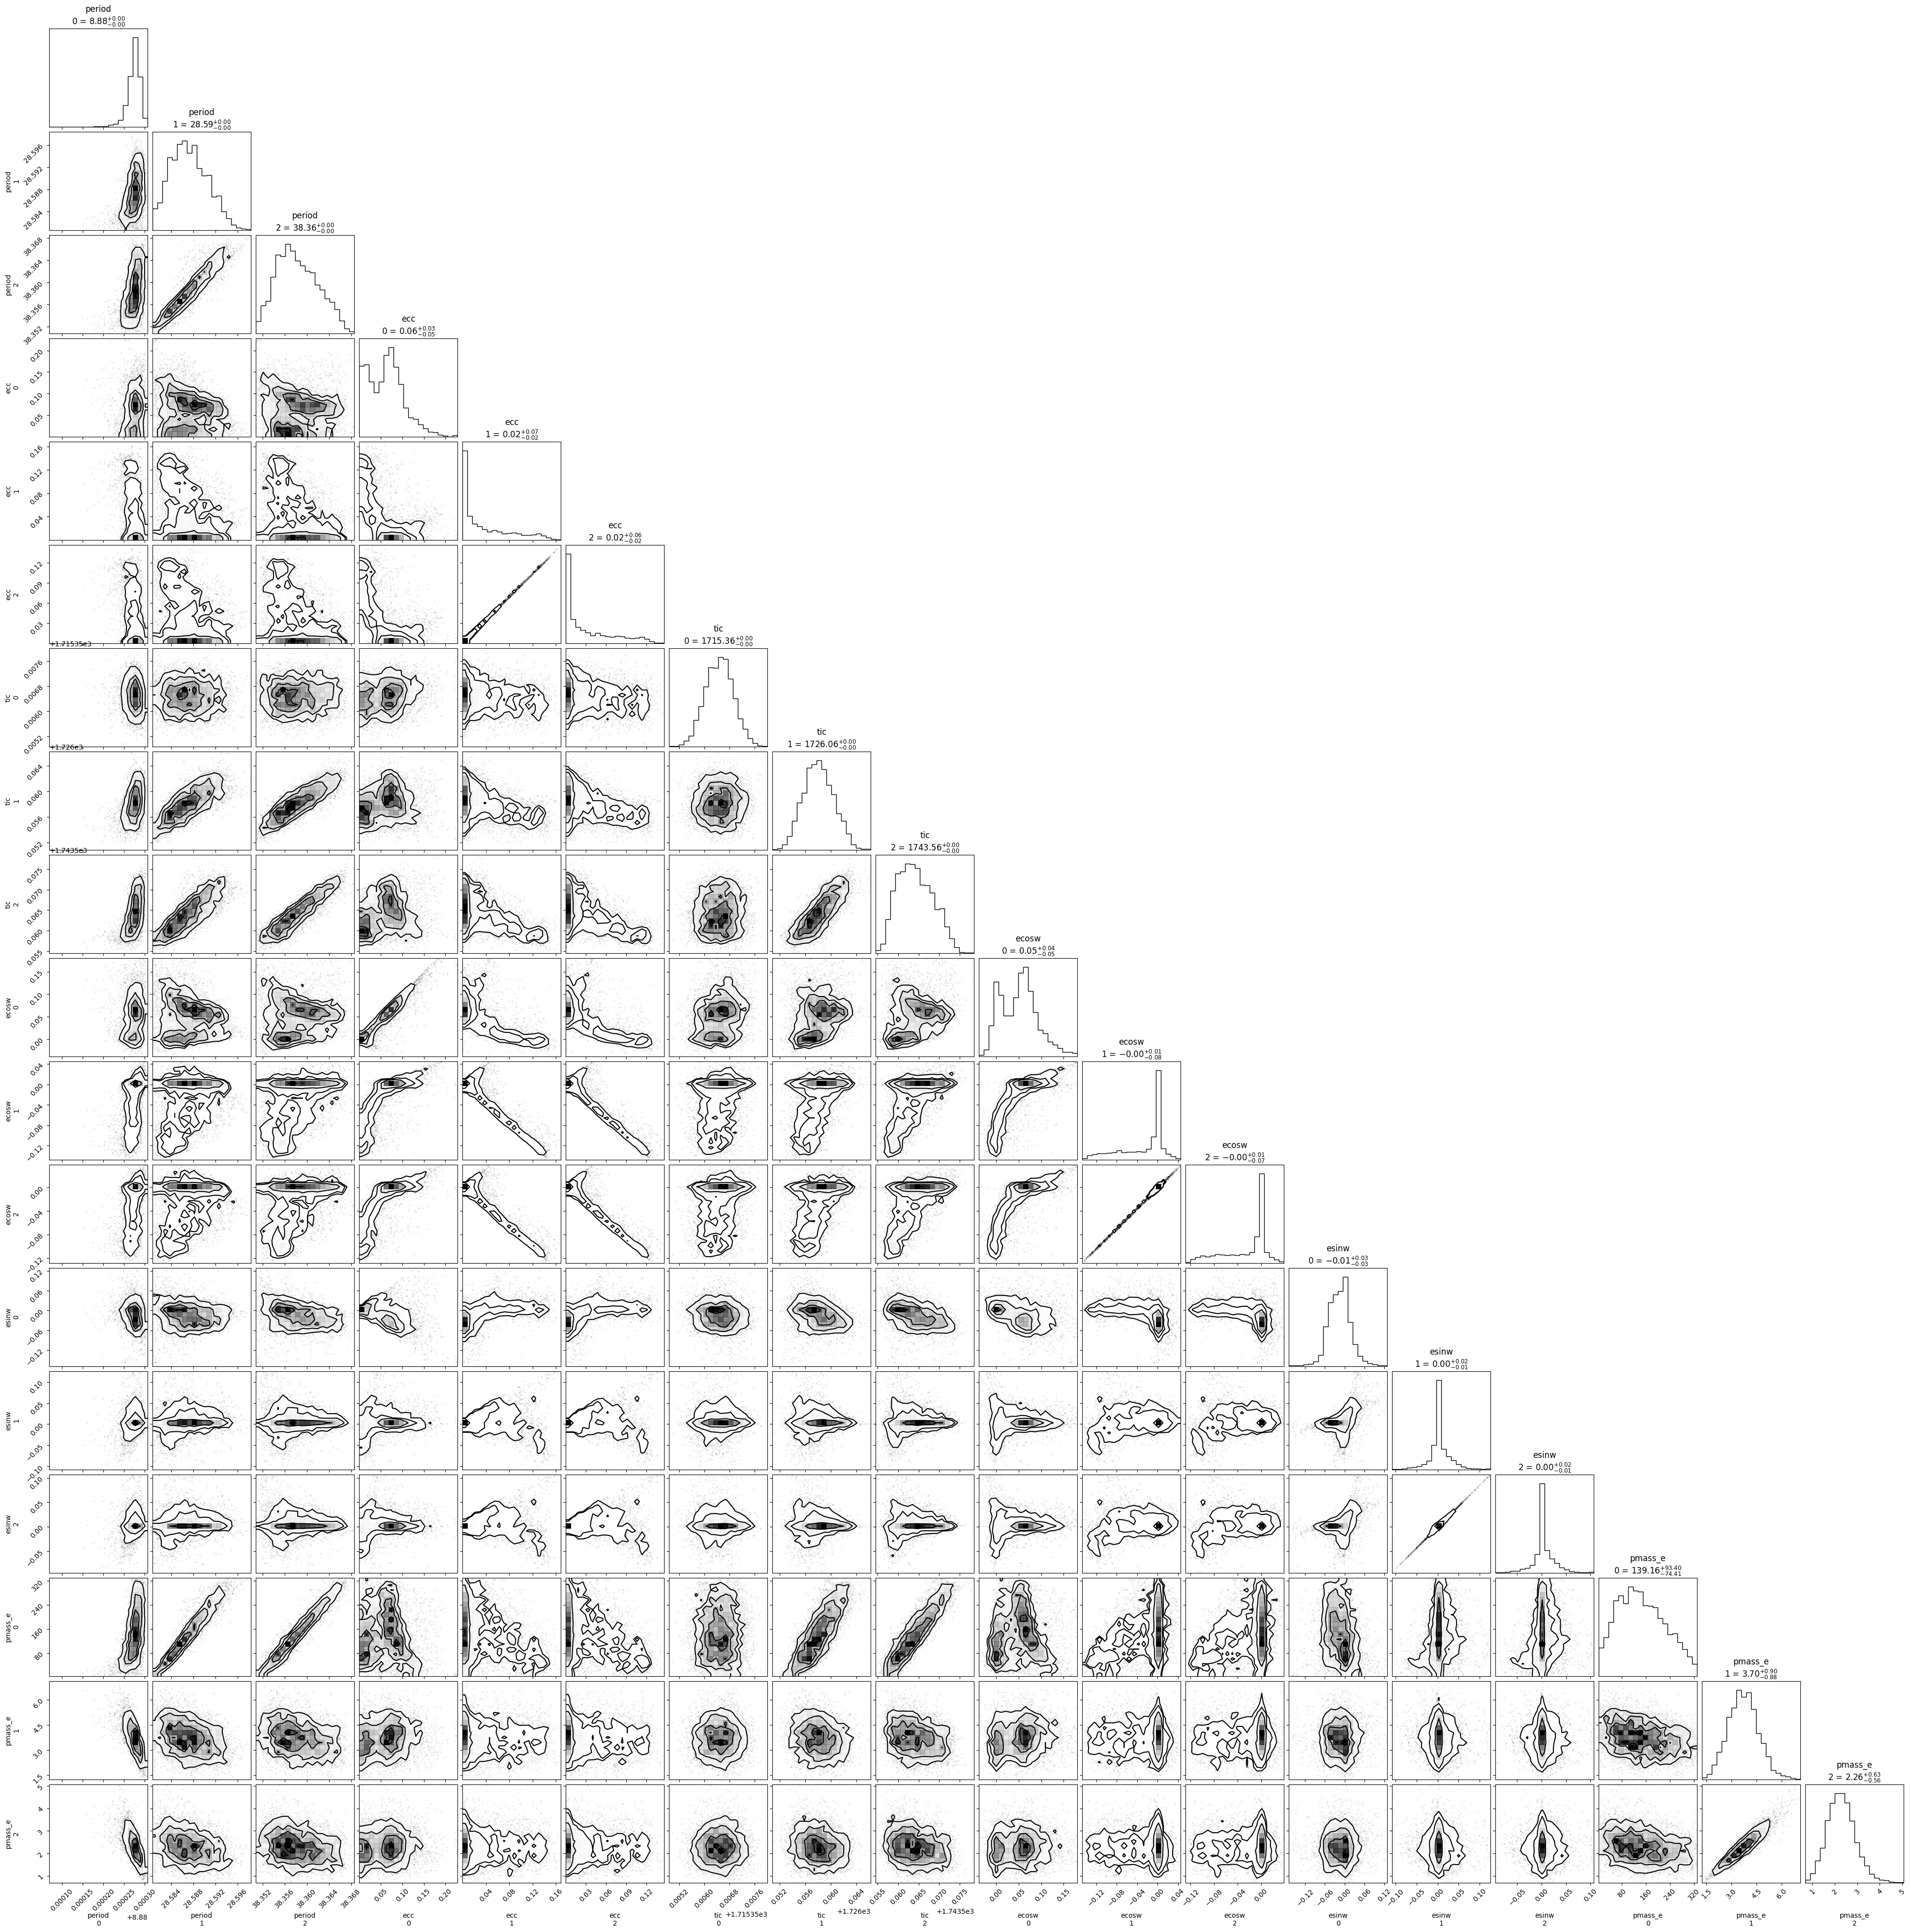

In [164]:
idata.posterior['pmass_e'] = idata.posterior['pmass'] / 3.003e-6
names = ["period", "ecc", "tic", "ecosw", "esinw", "pmass_e"]
fig = corner.corner(idata, var_names=names, show_titles=True)

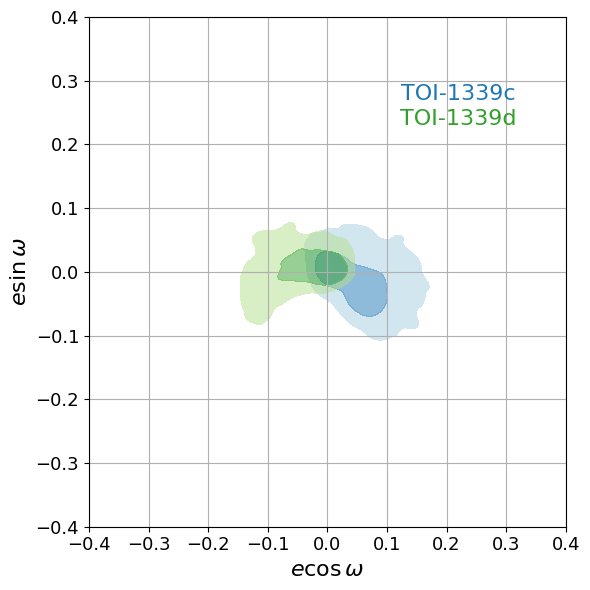

In [165]:
### 2D posterior for ecosw and esinw 
ecosw_c = samples["ecosw"][:, 0]
esinw_c = samples["esinw"][:, 0]

ecosw_d = samples["ecosw"][:, 1]
esinw_d = samples["esinw"][:, 1]

import matplotlib.pyplot as plt
# import seaborn as sns
from scipy.stats import gaussian_kde


def compute_kde_contour_levels(x, y, gridsize=100):
    data = np.vstack([x, y])
    kde = gaussian_kde(data)
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    X, Y = np.mgrid[x_min:x_max:gridsize*1j, y_min:y_max:gridsize*1j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kde(positions).T, X.shape)
    return X, Y, Z, kde

def get_sigma_contour_levels(Z):
    Z_flat = Z.flatten()
    Z_sorted = np.sort(Z_flat)[::-1]
    cumsum = np.cumsum(Z_sorted)
    cumsum /= cumsum[-1]
    levels = []
    for sigma in [0.683, 0.954]:
        idx = np.searchsorted(cumsum, sigma)
        levels.append(Z_sorted[idx])
    return sorted(levels)  # ensures ascending order

# Compute KDEs
Xc, Yc, Zc, kde_c = compute_kde_contour_levels(ecosw_c, esinw_c)
Xd, Yd, Zd, kde_d = compute_kde_contour_levels(ecosw_d, esinw_d)

# Get contour levels
levels_c = get_sigma_contour_levels(Zc)
levels_d = get_sigma_contour_levels(Zd)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Filled contours for planet c (blue shades)
ax.contourf(Xc, Yc, Zc, levels=levels_c + [Zc.max()], colors=['#a6cee3', '#1f78b4'], alpha=0.5)

# Filled contours for planet d (green shades)
ax.contourf(Xd, Yd, Zd, levels=levels_d + [Zd.max()], colors=['#b2df8a', '#33a02c'], alpha=0.5)

# Text annotation
ax.text(0.22, 0.27, 'TOI-1339c', color='#1f78b4', fontsize=16, ha='center')
ax.text(0.22, 0.23, 'TOI-1339d', color='#33a02c', fontsize=16, ha='center')


# Labels and legend
ax.set_xlabel(r"$e \cos\omega$", fontsize=16)
ax.set_ylabel(r"$e \sin\omega$", fontsize=16)
# ax.set_title("2D Joint Posterior of $e  cos(\omega)$ and $e sin(\omega)$")
blue_patch = plt.Line2D([], [], color='#a6cee3', label='Planet c')
red_patch = plt.Line2D([], [], color='#b2df8a', label='Planet d')
# ax.legend(handles=[blue_patch, red_patch])


# plt.grid(True)
plt.tick_params(axis='both', labelsize=13) 
plt.xlim(-0.40,0.40)
plt.ylim(-0.40,0.40)
plt.grid(True)
plt.tight_layout()
plt.show()

# check transit fits 

In [191]:
d = pd.read_csv("toi_1339_transit_data_all_planets.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])

tcobs = [jnp.array(d.Tc[d.Planet_num==j+1]) for j in range(3)]
errorobs = [jnp.array(d.Tc_err[d.Planet_num==j+1]) for j in range(3)]
p_init = [8.88020257, 28.58140011, 38.35180318]


t_start = 1715.  # start of integration
t_end = 3670.
dt = p_init[0] / 40. # integration timestep

# detrended light curves around transits; here simultaneous transit is excluded
dlc = pd.read_csv("TOI1339_lc_photodyn.csv")
time_obs = jnp.array(dlc['time'])
flux_obs = jnp.array(dlc['flux']) - 1.  # normalize around 0
error_obs = jnp.array(dlc['flux_err'])

# Get the sorting indices
sort_idx = np.argsort(time_obs)

# Apply the same reordering to all arrays
time_obs = time_obs[sort_idx]
flux_obs = flux_obs[sort_idx]
error_obs = error_obs[sort_idx]

window = 0.6  # days
time_segments, flux_segments, error_segments = [], [], []

planet_ids = []

for planet_idx, tplanet in enumerate(tcobs):
    for t0 in tplanet:
        mask = (time_obs > t0 - window) & (time_obs < t0 + window)
        time_segments.append(time_obs[mask])
        flux_segments.append(flux_obs[mask])
        error_segments.append(error_obs[mask])
        planet_ids.append(np.ones(np.sum(mask)) * planet_idx)

# Concatenate segments
time_obs_trim = np.concatenate(time_segments)
flux_obs_trim = np.concatenate(flux_segments)
error_obs_trim = np.concatenate(error_segments)
planet_ids = np.concatenate(planet_ids).astype(int)

time_obs = jnp.array(time_obs_trim)
flux_obs = jnp.array(flux_obs_trim)
error_obs = jnp.array(error_obs_trim)
planet_ids = jnp.array(planet_ids)  


############## bin
from scipy.stats import binned_statistic

kepler_bin = 29.4
tess_bin = 2.0
def bin_light_curve(time, flux, flux_err, bin_width=kepler_bin/1440.):
    """
    Bin the light curve by computing the weighted mean flux in each time bin.

    Parameters:
    - time: array-like, time values (unevenly spaced)
    - flux: array-like, flux measurements corresponding to time
    - flux_err: array-like, flux measurement errors
    - bin_width: float, width of each time bin (same units as time)

    Returns:
    - bin_centers: array of bin center times
    - binned_flux: array of weighted mean flux per bin
    - binned_err: array of error on weighted mean flux per bin
    - bin_counts: number of points per bin
    """

    # Define bin edges
    t_min, t_max = np.min(time), np.max(time)
    bins = np.arange(t_min, t_max + bin_width, bin_width)

    # Which bin each point belongs to
    binnumber = np.digitize(time, bins) - 1
    nbins = len(bins) - 1

    # Weights from errors
    w = 1.0 / flux_err**2

    # Weighted sums
    sum_w  = np.bincount(binnumber, weights=w, minlength=nbins)
    sum_fw = np.bincount(binnumber, weights=flux * w, minlength=nbins)

    # Weighted mean and its error
    binned_flux = np.full(nbins, np.nan)
    binned_err  = np.full(nbins, np.nan)

    mask = sum_w > 0
    binned_flux[mask] = sum_fw[mask] / sum_w[mask]
    binned_err[mask]  = np.sqrt(1.0 / sum_w[mask])

    # Counts per bin
    bin_counts = np.bincount(binnumber, minlength=nbins)

    # Bin centers
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    return bin_centers, binned_flux, binned_err, bin_counts

idx_bin = time_obs > 0 #2250
#plt.xlim(3480, 3482)
# plt.plot(time_obs[idx_bin], flux_obs[idx_bin], '.')
tbin, fbin, ferr, counts = bin_light_curve(time_obs[idx_bin], flux_obs[idx_bin], error_obs[idx_bin])
idxc = counts > 5
# planet ids 
planet_bin = []
bin_width = kepler_bin
binnumber = np.digitize(time_obs[idx_bin], 
                        np.arange(tbin[0]-bin_width/2, tbin[-1]+bin_width/2, bin_width)) - 1
for i in range(len(tbin)):
    mask = binnumber == i
    if np.any(mask):
        # majority vote for planet id inside this bin
        pid = np.bincount(planet_ids[idx_bin][mask]).argmax()
        planet_bin.append(pid)
    else:
        planet_bin.append(-1)  # placeholder for empty bin

planet_bin = np.array(planet_bin)
planet_ids = np.r_[planet_ids[~idx_bin], planet_bin[idxc]]

time_obs = np.r_[time_obs[~idx_bin], tbin[idxc]]
flux_obs = np.r_[flux_obs[~idx_bin], fbin[idxc]]
error_obs = np.r_[error_obs[~idx_bin], ferr[idxc]]


time_obs = np.array(time_obs)
flux_obs = np.array(flux_obs)
error_obs = np.array(error_obs)
planet_ids = np.array(planet_ids)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_75052/2643692688.py:1: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv("toi_1339_transit_data_all_planets.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


In [192]:
samples = mcmc.get_samples()
models = samples['fluxmodel'] + samples['meanflux'][:,None]
gppreds = samples['gppred']
models_mean, models_sd = np.mean(models, axis=0), np.std(models, axis=0)
gp_mean, gp_sd = np.mean(gppreds, axis=0), np.std(gppreds, axis=0)


print(len(models))
print(len(gppreds))
print(len(models_mean))
print(len(models_sd))
print(len(gp_mean))
print(len(gp_sd))

target_len = len(flux_obs)  # or len(time_obs), they should match

# Trim the model arrays to match observations
models_mean = models_mean[:target_len]
models_sd   = models_sd[:target_len]
gp_mean     = gp_mean[:target_len]
gp_sd       = gp_sd[:target_len]


print(flux_obs)
print(len(flux_obs))
print(models_mean)
print(len(models_mean))


print(len(time_obs))
print(len(time_obs))

4000
4000
6125
6125
6125
6125
[-8.11941238e-05  1.11785762e-04 -1.08770659e-05 ...  1.40432695e-04
  7.17529895e-05 -2.26559359e-05]
6124
[2.99380298e-05 2.99380298e-05 2.99380298e-05 ... 2.99380298e-05
 2.99380298e-05 2.99380298e-05]
6124
6124
6124


In [201]:
from scipy.stats import binned_statistic

def bin_light_curve(time, flux, bin_width=2.0/1440.):
    """
    Bin the light curve by computing the mean flux in each time bin.

    Parameters:
    - time: array-like, time values (unevenly spaced)
    - flux: array-like, flux measurements corresponding to time
    - bin_width: float, width of each time bin in the same units as time (default: 2.0)

    Returns:
    - bin_centers: array of bin center times
    - binned_flux: array of mean flux values per bin
    - bin_counts: number of points per bin
    """

    # Define bin edges
    t_min, t_max = np.min(time), np.max(time)
    bins = np.arange(t_min, t_max + bin_width, bin_width)

    # Compute binned statistics
    binned_flux, bin_edges, binnumber = binned_statistic(time, flux, statistic='median', bins=bins)
    bin_counts, _, _ = binned_statistic(time, flux, statistic='count', bins=bins)

    # Compute bin centers
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.

    return bin_centers, binned_flux, bin_counts


def plot_lcmodels(nt, models_mean, gp_mean, markersize=5):
    t_bin, f_bin, counts = bin_light_curve(time_obs, flux_obs, 30.0/1440.)
    idx_ = counts > 5
    t_bin, f_bin = t_bin[idx_], f_bin[idx_]
    tres_bin, fres_bin, counts = bin_light_curve(time_obs, flux_obs-models_mean-gp_mean, 30./1440.)
    idx_ = counts > 5
    tres_bin, fres_bin = tres_bin[idx_], fres_bin[idx_]

    scale = 1e3
    rows, col = [len(nt.tcobs[j])//5+1 for j in range(len(nt.tcobs))], 5
    plnames = [f'planet{i}+1' for i in range(len(nt.tcobs))]
    for j in range(len(plnames)):
        fig, axes = plt.subplots(rows[j], col, sharey=True, figsize=(12, rows[j]*2))
        fig.text(0.5, -0.01, 'time (days)', ha='center', fontsize=24)
        fig.text(-0.03, 0.5, r'relative flux ($\times 10^{-3}$)', va='center', rotation='vertical', fontsize=24)
        tcs = nt.tcobs[j]

        for k,tc in enumerate(tcs):
            ax = axes[k // col, k % col]
            idx = np.abs(time_obs - tc) < 0.4
            if not np.sum(idx):
                continue

            t_, f_ = time_obs[idx], flux_obs[idx]*scale
            ax.set_xlim(t_[0], t_[-1])
            ax.plot(t_, f_, '.', alpha=0.5, color='gray', label='data', markersize=markersize)
            idxb = np.abs(t_bin - tc) < 0.4
            ax.plot(t_bin[idxb], f_bin[idxb]*scale, 'o', markersize=3, mfc='white', color='gray')
            
            fm0 = models_mean[idx]
            mu = (models_mean + gp_mean)[idx]
            #sigma = (models_sd + gp_sd)[idx]
            ax.plot(t_, mu*scale, '-', color='C1', lw=1)
            #ax.fill_between(t_, (mu-sigma)*scale, (mu+sigma)*scale, color='C1', alpha=0.2)

            offset = -1.2 * np.min(f_) + 7 * np.std(f_ - mu*scale)
            ax.plot(t_, (f_-mu*scale)-offset, '.', alpha=0.5, color='gray', label='data', markersize=markersize)
            ax.axhline(y=-offset, color='C1', lw=1)
            idxb = np.abs(tres_bin - tc) < 0.4
            ax.plot(tres_bin[idxb], fres_bin[idxb]*scale-offset, 'o', markersize=3, mfc='white', color='gray')

        for kdel in range(k+1, rows[j]*col):
            fig.delaxes(axes[kdel // col, kdel % col])
        fig.tight_layout(pad=0.02)


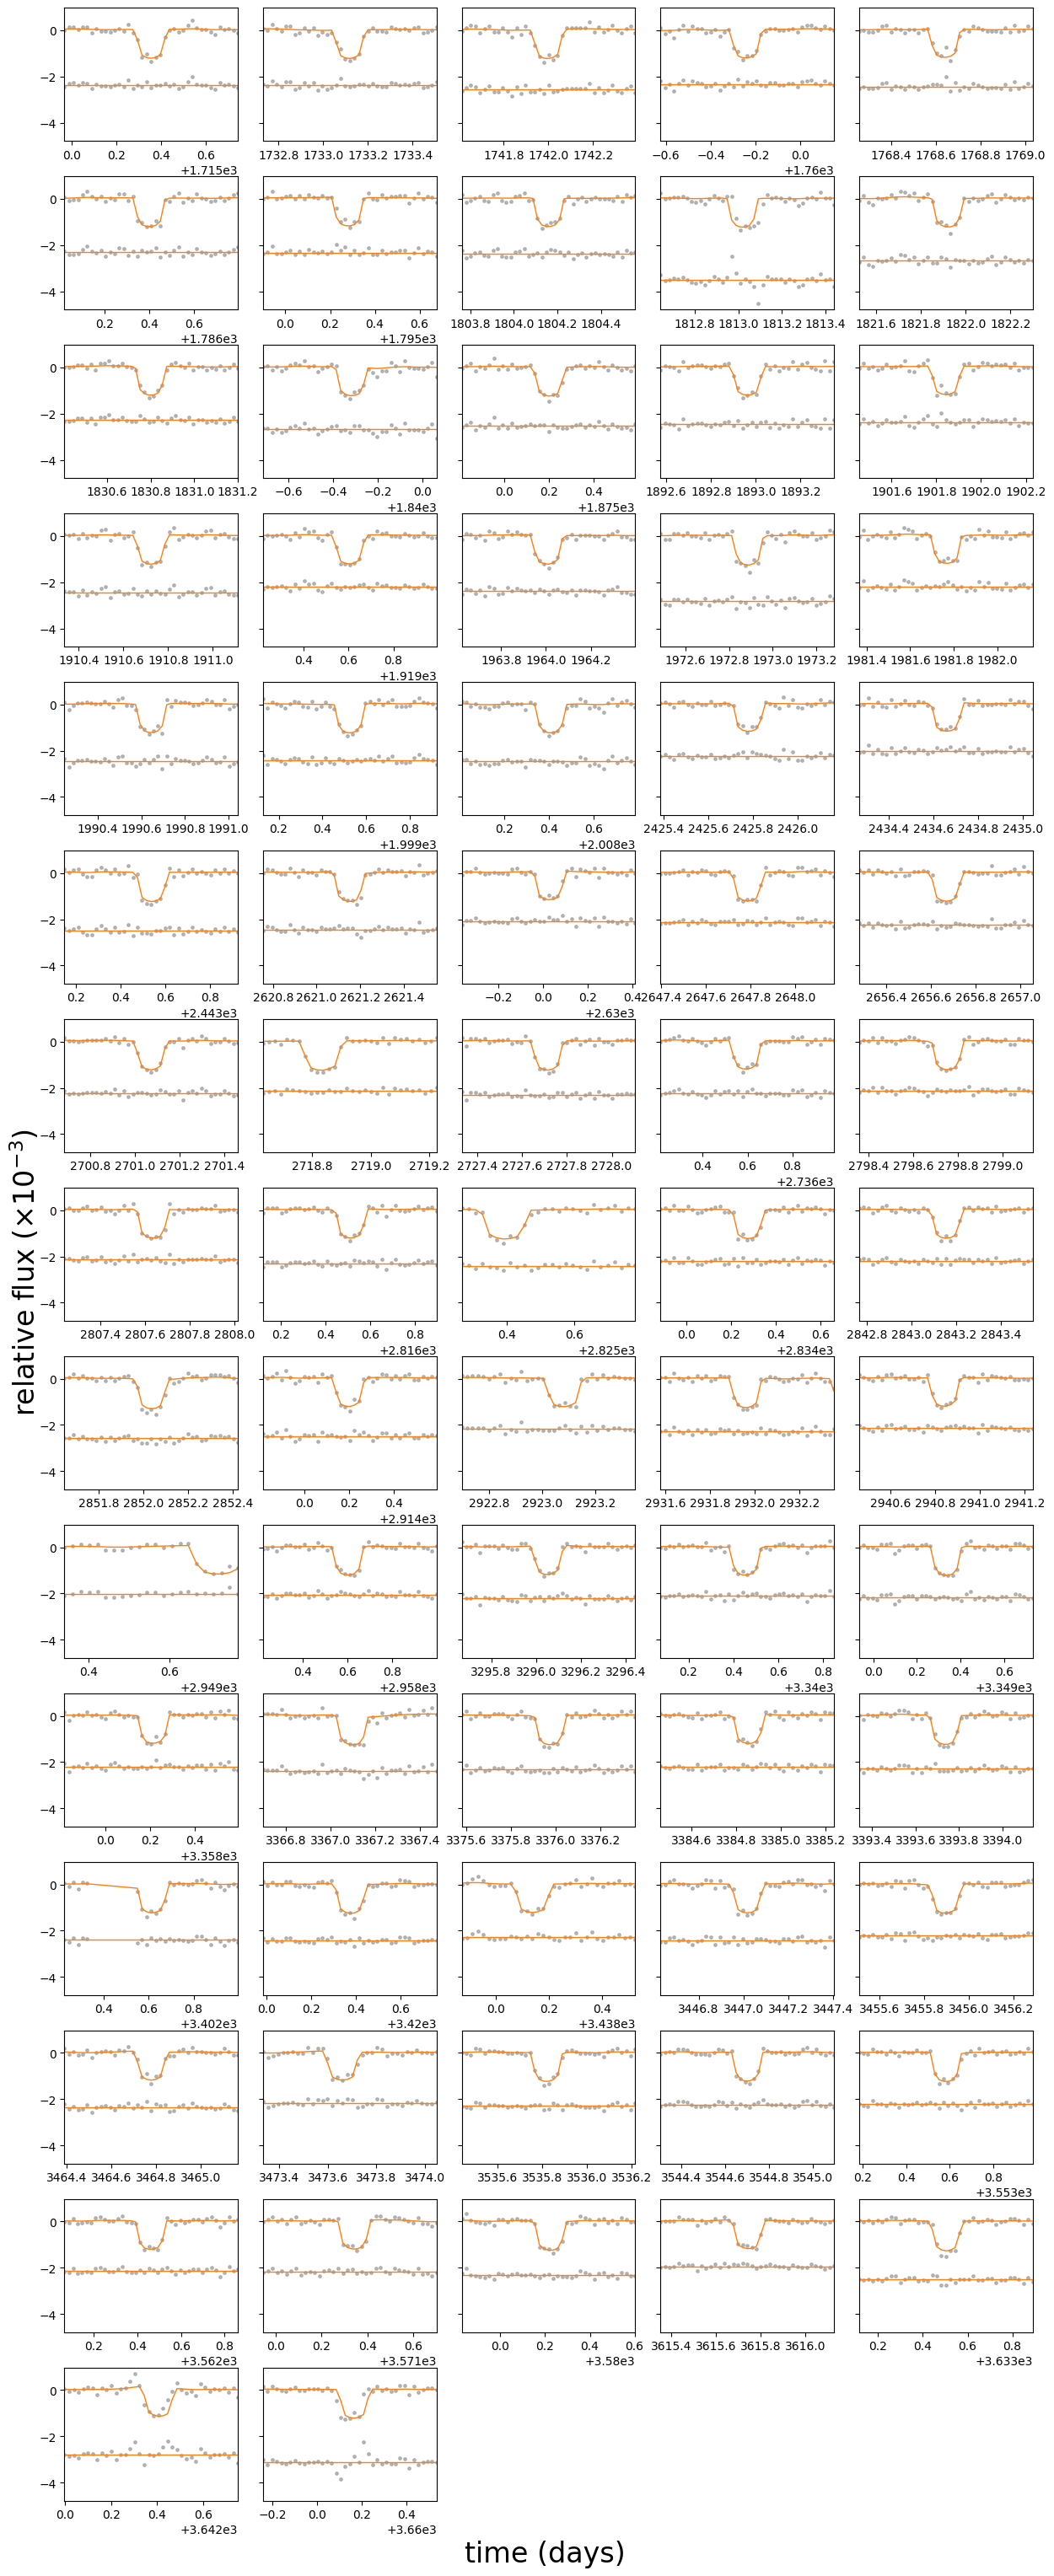

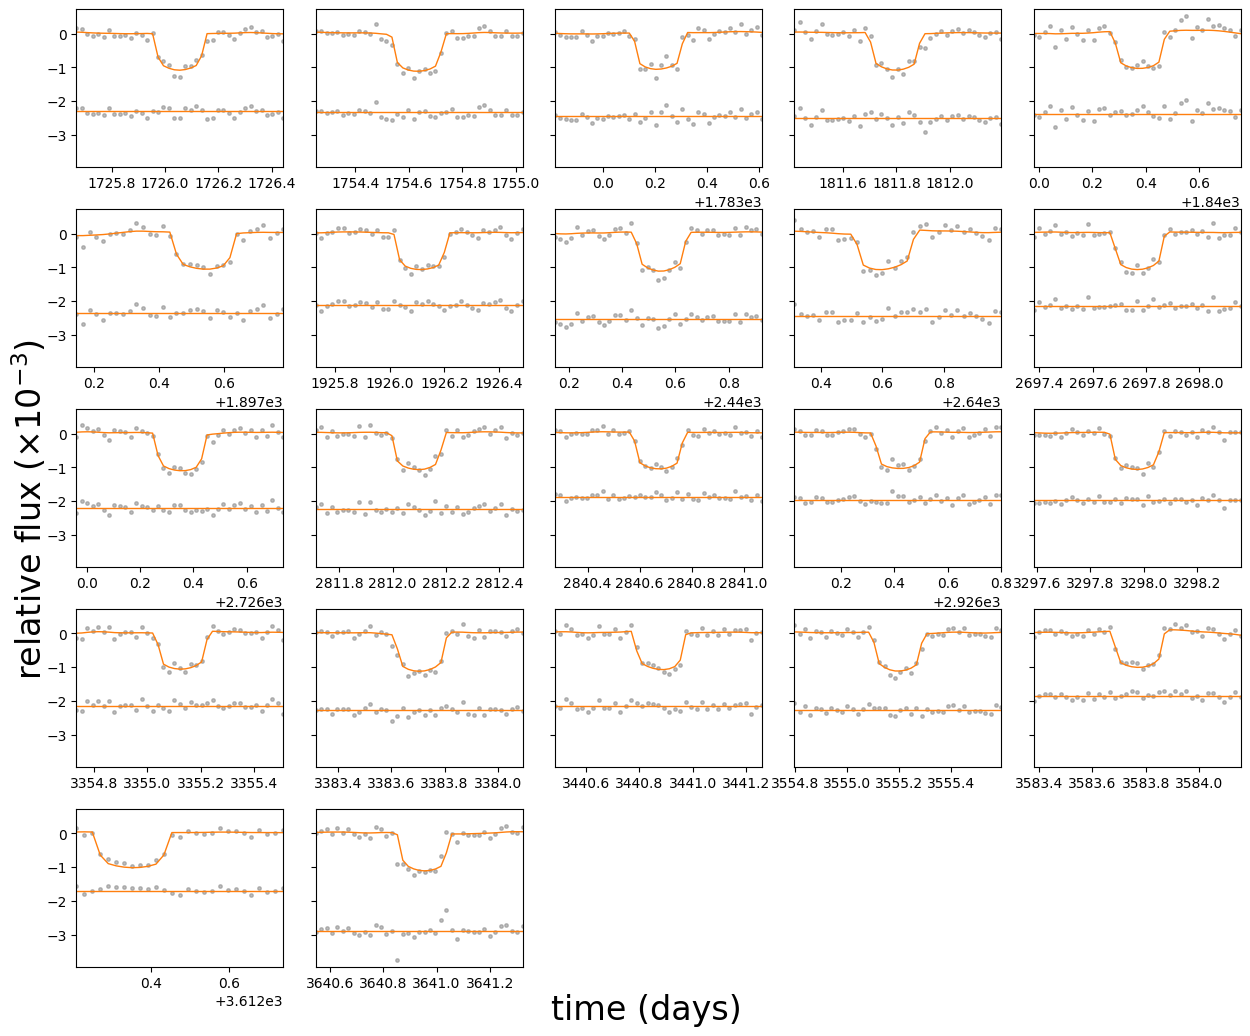

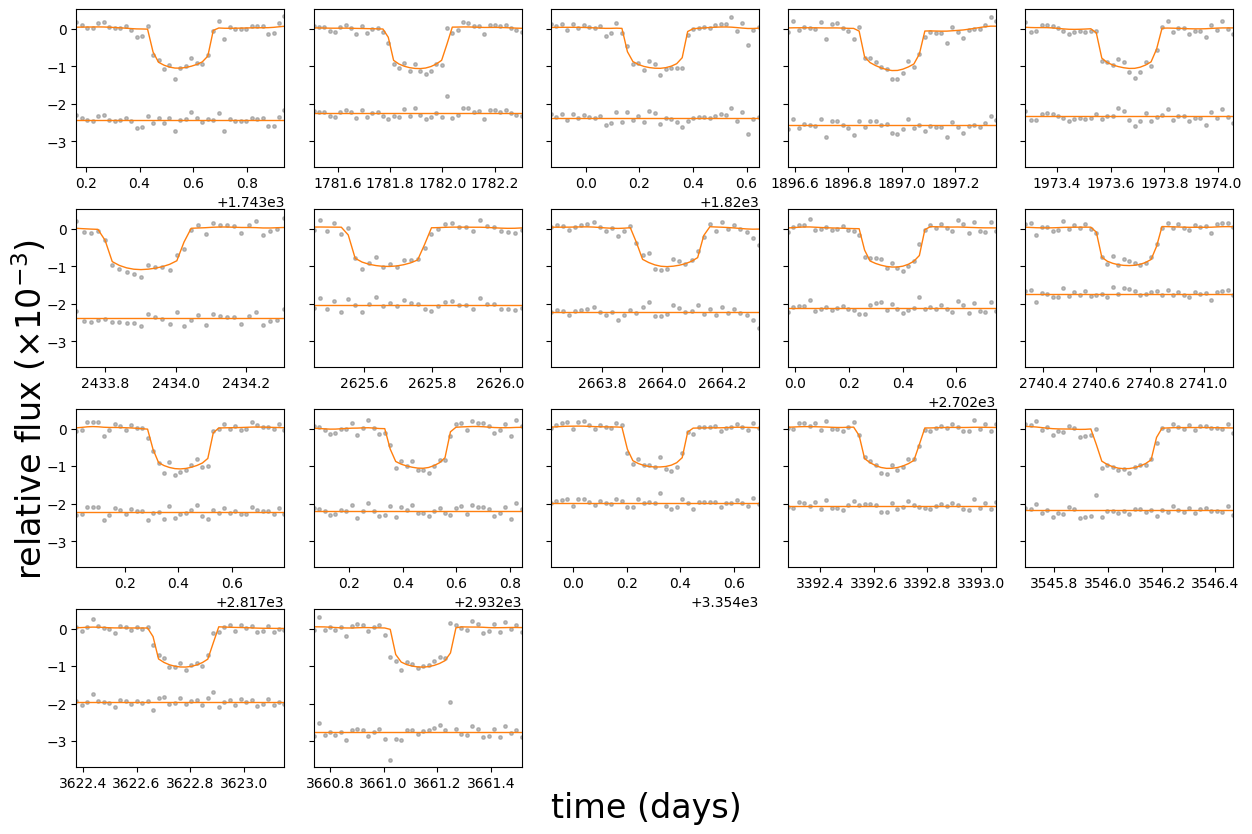

In [202]:
plot_lcmodels(nt, models_mean, gp_mean)

3660.1447115


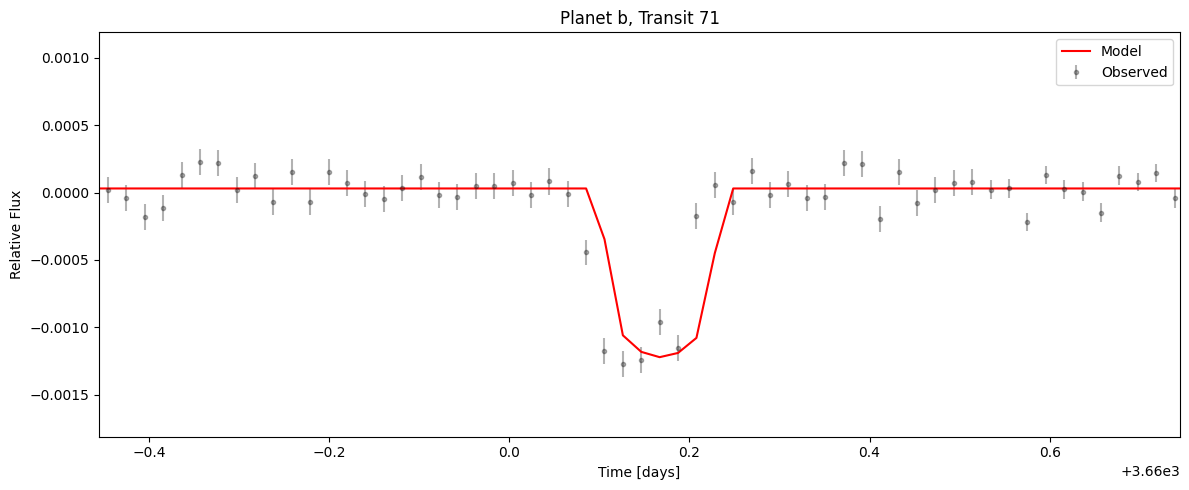

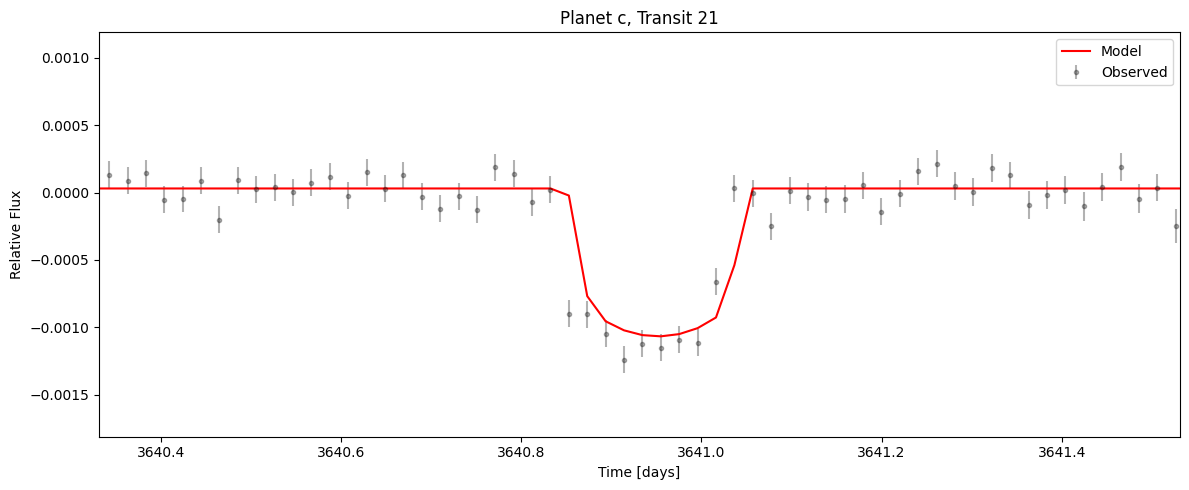

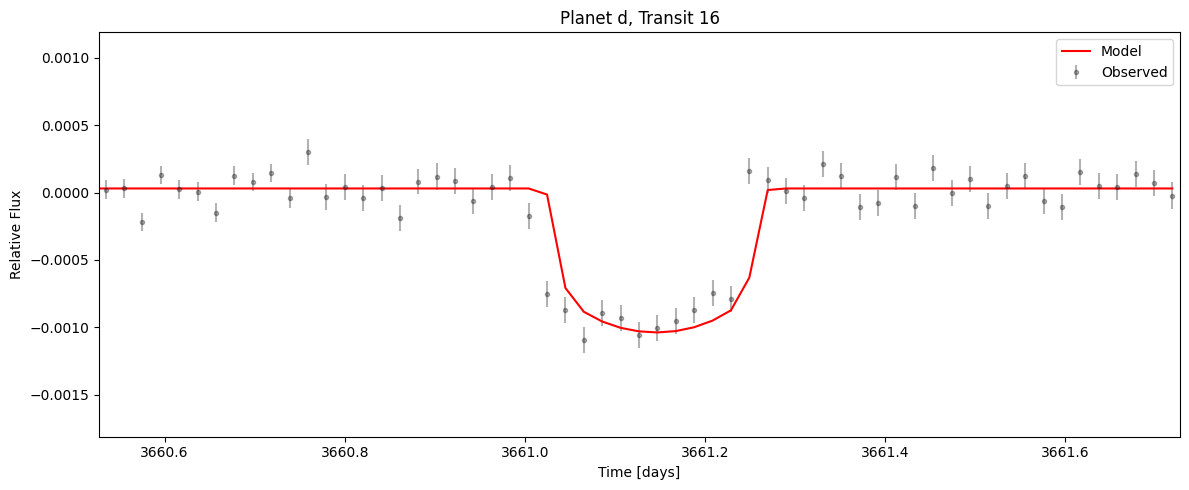

In [223]:
# Build parameter dictionary for the final model
par_model = {}
for key in list(popt_full.keys()) + list(popt_transit.keys()):
    par_model[key] = popt_full.get(key, popt_transit.get(key))

# Evaluate the flux model on the observed times
flux_model, tc_model = nt.get_flux(par_model)
flux_model= flux_model[:target_len]
tc_model = tc_model[:target_len]

transit_num = 71
transit_time = tcobs[0][transit_num]
print(transit_time)


# Plot
plt.figure(figsize=(12, 5))
plt.errorbar(time_obs, flux_obs, yerr=error_obs, fmt=".k", alpha=0.3, label="Observed")
plt.plot(time_obs, flux_model + par_model["meanflux"], "r-", lw=1.5, label="Model")
plt.title(f"Planet b, Transit {transit_num}")
plt.xlabel("Time [days]")
plt.ylabel("Relative Flux")
plt.xlim(transit_time-0.6,transit_time+0.6)
plt.legend()
plt.tight_layout()
plt.show()

transit_num = 21
transit_time = tcobs[1][transit_num]
# Plot
plt.figure(figsize=(12, 5))
plt.errorbar(time_obs, flux_obs, yerr=error_obs, fmt=".k", alpha=0.3, label="Observed")
plt.plot(time_obs, flux_model + par_model["meanflux"], "r-", lw=1.5, label="Model")
plt.title(f"Planet c, Transit {transit_num}")
plt.xlabel("Time [days]")
plt.ylabel("Relative Flux")
plt.xlim(transit_time-0.6,transit_time+0.6)
plt.legend()
plt.tight_layout()
plt.show()

transit_num = 16
transit_time = tcobs[2][transit_num]
# Plot
plt.figure(figsize=(12, 5))
plt.errorbar(time_obs, flux_obs, yerr=error_obs, fmt=".k", alpha=0.3, label="Observed")
plt.plot(time_obs, flux_model + par_model["meanflux"], "r-", lw=1.5, label="Model")
plt.title(f"Planet d, Transit {transit_num}")
plt.xlabel("Time [days]")
plt.ylabel("Relative Flux")
plt.xlim(transit_time-0.6,transit_time+0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Remove outlier chain

In [15]:
mcmc.print_summary()
posterior = mcmc.get_samples(group_by_chain=True)  # shape: (num_chains, num_samples, ...)
print({k: v.shape for k, v in posterior.items()})


                      mean       std    median      5.0%     95.0%     n_eff     r_hat
 ecosw_scaled[0]      0.42      0.09      0.44      0.28      0.52     43.49      1.11
 ecosw_scaled[1]      0.43      0.08      0.46      0.31      0.52     43.92      1.11
 esinw_scaled[0]      0.48      0.07      0.50      0.35      0.57    207.79      1.05
 esinw_scaled[1]      0.48      0.06      0.50      0.38      0.56    206.88      1.05
period_scaled[0]      0.50      0.00      0.50      0.50      0.50     48.02      1.10
period_scaled[1]      0.50      0.00      0.50      0.50      0.50    281.11      1.02
 pmass_scaled[0]      0.02      0.00      0.02      0.01      0.03    143.77      1.06
 pmass_scaled[1]      0.01      0.00      0.01      0.01      0.02     76.66      1.08
   tic_scaled[0]      0.48      0.01      0.48      0.47      0.49     32.08      1.14
   tic_scaled[1]      0.52      0.02      0.52      0.48      0.55    195.05      1.04

Number of divergences: 4
{'ecc': (8, 1000

In [16]:
good_chain_idxs = [0,2,3,5,6,7]

samples_filtered = {
    k: v[good_chain_idxs, ...] for k, v in posterior.items()
}
# print(samples_filtered)
samples_flat = {
    k: v.reshape(-1, *v.shape[2:]) for k, v in samples_filtered.items()
}


In [17]:
means, stds = jttv.sample_means_and_stds(samples_flat, truncate=False)

/opt/homebrew/anaconda3/envs/hd191939/lib/python3.13/site-packages/jnkepler/jaxttv/jaxttv.py:531: UserWarning: using t0 and P from a linear fit to the observed transit times.
  warnings.warn(


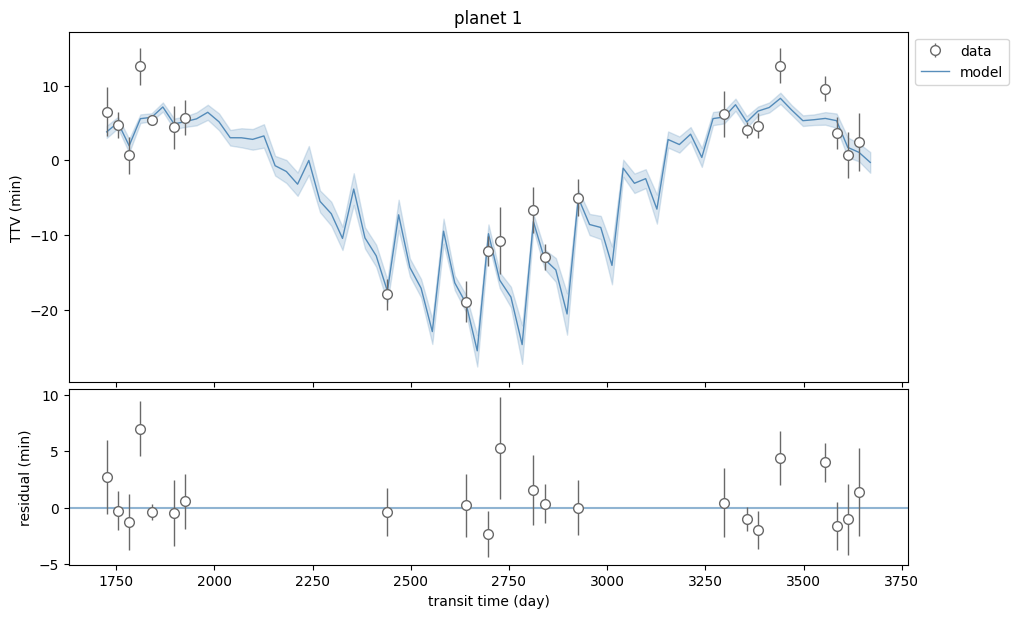

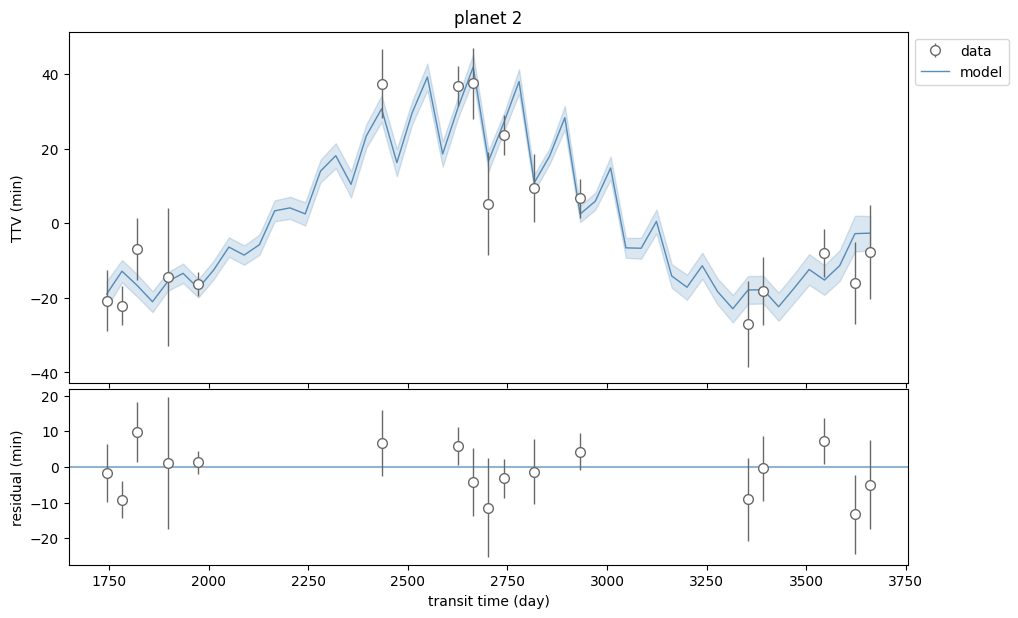

In [18]:
jttv.plot_model(means, tcmodelunclist=stds)

In [19]:
def ephem(p,tc,ind):
    t = tc + (p*ind)
    return t

d = pd.read_csv("toi_1339_transit_data_all.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])
index_obs_c = np.array(d.Index[d.Planet_num==2])
index_obs_d = np.array(d.Index[d.Planet_num==3])


t_jnkep_c = means[0]
t_jnkep_d = means[1]
t_jnkep_err_c = stds[0]
t_jnkep_err_d = stds[1]

best_fit_period_c = np.median(samples_flat['period'][:,0])
best_fit_period_d = np.median(samples_flat['period'][:,1])

best_fit_tc_c = np.median(samples_flat['tic'][:,0])
best_fit_tc_d = np.median(samples_flat['tic'][:,1])

t_obs_c = jttv.tcobs[0]
t_obs_d = jttv.tcobs[1]
t_obs_err_c = jttv.errorobs[0]
t_obs_err_d = jttv.errorobs[1]

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_75052/3926649874.py:5: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv("toi_1339_transit_data_all.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


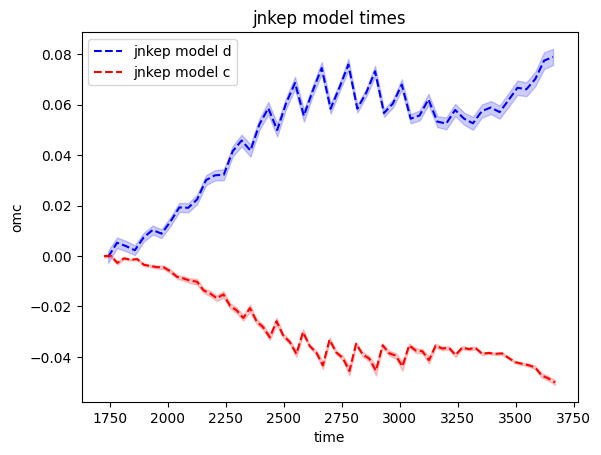

In [20]:
### plot the jnkep model
ind_jnkep_c = np.arange(0,(len(np.array(t_jnkep_c))), 1)
ind_jnkep_d = np.arange(0,(len(np.array(t_jnkep_d))), 1)

jnkep_ephem_time_d = ephem(best_fit_period_d, best_fit_tc_d, ind_jnkep_d)
jnkep_ephem_time_c = ephem(best_fit_period_c, best_fit_tc_c, ind_jnkep_c)

jnkep_omc_d = t_jnkep_d - jnkep_ephem_time_d
jnkep_omc_c = t_jnkep_c - jnkep_ephem_time_c

# plt.plot(t_jnkep_b, jnkep_omc_b, label='jnkep model b', c='g')
# plt.plot(t_jnkep_c, jnkep_omc_c, label='jnkep model c', c='r')

# Plotting
plt.plot(t_jnkep_d, jnkep_omc_d, label='jnkep model d', linestyle='--', color='b')
plt.fill_between(t_jnkep_d,
                 jnkep_omc_d - t_jnkep_err_d,
                 jnkep_omc_d + t_jnkep_err_d,
                 color='b', alpha=0.2)

plt.plot(t_jnkep_c, jnkep_omc_c, label='jnkep model c', linestyle='--', color='r')
plt.fill_between(t_jnkep_c,
                 jnkep_omc_c - t_jnkep_err_c,
                 jnkep_omc_c + t_jnkep_err_c,
                 color='r', alpha=0.2)

plt.title('jnkep model times')
plt.xlabel('time')
plt.ylabel('omc')
plt.legend()
plt.show()

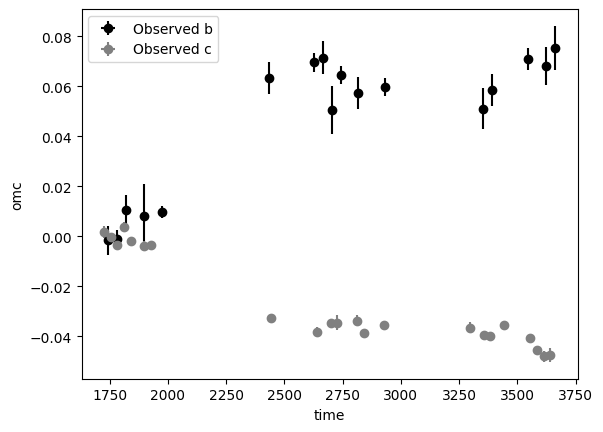

In [21]:
### adding observed data
### same ephem as the model and predictions 
index_obs_d = np.array(index_obs_d)
index_obs_c = np.array(index_obs_c)
omc_obs_d= t_obs_d - ephem(best_fit_period_d, best_fit_tc_d, index_obs_d)
omc_obs_c = t_obs_c - ephem(best_fit_period_c, best_fit_tc_c, index_obs_c)


offset_obs_c = 0
offset_obs_d = 0

plt.errorbar(t_obs_d, omc_obs_d - offset_obs_d, xerr=t_obs_err_d, yerr=t_obs_err_d, marker='o', linestyle='none', label='Observed b', c='black')
plt.errorbar(t_obs_c, omc_obs_c - offset_obs_c, xerr=t_obs_err_c, yerr=t_obs_err_c, marker='o', linestyle='none', label='Observed c', c='grey')

# plt.title('Petigura and Jnkep models')
plt.xlabel('time')
plt.ylabel('omc')
# plt.xlim(2027.88,2027.92)
# plt.xlim(1900,5500)

plt.legend()
plt.show()

In [22]:
# Use a linear fit (degree=1) to get slope and intercept
c_coeffs = np.polyfit(t_jnkep_c, jnkep_omc_c, 1)
c_slope = c_coeffs[0]
print(f'c slope for jnkep model (from linear fit): {c_slope}')
d_coeffs = np.polyfit(t_jnkep_d, jnkep_omc_d, 1)
d_slope = d_coeffs[0]
print(f'd slope for jnkep model (from linear fit): {d_slope}')
print(d_coeffs)

c slope for jnkep model (from linear fit): -2.375707731133228e-05
d slope for jnkep model (from linear fit): 3.282817171771921e-05
[ 3.28281717e-05 -4.08536692e-02]


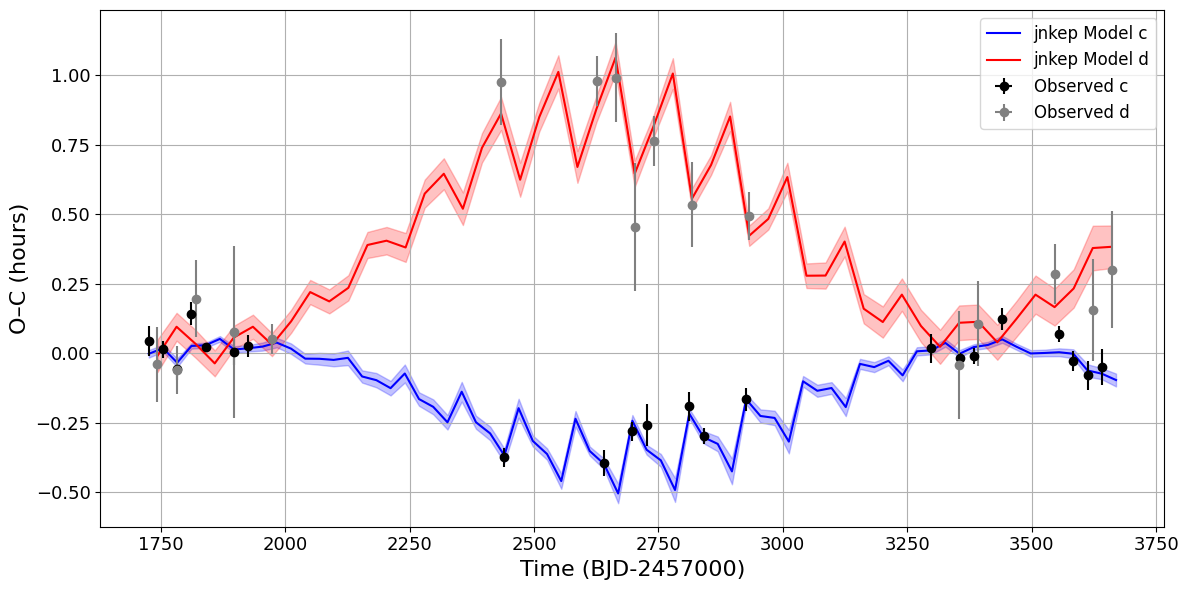

In [23]:
### Fit the linear trend for b and c (using numpy.polyfit)
def apply_trend(t, y, slope):
    # Ensure t and y are NumPy arrays
    t = np.asarray(t)
    y = np.asarray(y)
    # Remove slope, pivot about the first point
    return y - slope * (t - t[0])

### Planet b - Flatten the data
flat_jnkep_d = apply_trend(t_jnkep_d, jnkep_omc_d, d_slope)
flat_obs_d = apply_trend(t_obs_d, (omc_obs_d-offset_obs_d), d_slope)

### Planet c - Flatten the data
flat_jnkep_c = apply_trend(t_jnkep_c, jnkep_omc_c, c_slope)
flat_obs_c = apply_trend(t_obs_c, (omc_obs_c-offset_obs_c), c_slope)

### Plot flattened data
plt.figure(figsize=(12, 6))

flat_obs_d = np.array(flat_obs_d)
t_obs_err_d = np.array(t_obs_err_d)
flat_obs_c = np.array(flat_obs_c)
t_obs_err_c = np.array(t_obs_err_c)


### Plot for Planet c
# plt.plot(t_jnkep_c, flat_jnkep_c, label='jnkep Model c (flattened)',c='r')
plt.plot(t_jnkep_c, flat_jnkep_c*24, label='jnkep Model c', color='b')
plt.fill_between(t_jnkep_c,
                 (flat_jnkep_c - t_jnkep_err_c)*24,
                 (flat_jnkep_c + t_jnkep_err_c)*24,
                 color='b', alpha=0.24)

### Plot for Planet d
# plt.plot(t_jnkep_b, flat_jnkep_b, label='jnkep Model b (flattened)',c='g')
plt.plot(t_jnkep_d, flat_jnkep_d*24, label='jnkep Model d', color='r')
plt.fill_between(t_jnkep_d,
                 (flat_jnkep_d - t_jnkep_err_d)*24,
                 (flat_jnkep_d + t_jnkep_err_d)*24,
                 color='r', alpha=0.24)



plt.errorbar(t_obs_c, flat_obs_c*24, xerr=t_obs_err_c, yerr=t_obs_err_c*24, marker='o', linestyle='none', label='Observed c', c='black')
plt.errorbar(t_obs_d, flat_obs_d*24, xerr=t_obs_err_d, yerr=t_obs_err_d*24, marker='o', linestyle='none', label='Observed d', c='grey')

### Customize the plot
# plt.title('Flattened O–C') # (Slope Removed, Pivoted at First Point)
plt.xlabel(f'Time (BJD-{TESS_offset})', fontsize=16)
plt.ylabel('O–C (hours)', fontsize=16)
# plt.xlim(1850,5500)
plt.legend(fontsize=12)
plt.tick_params(axis='both', labelsize=13)
plt.grid(True)
plt.tight_layout()
plt.show()

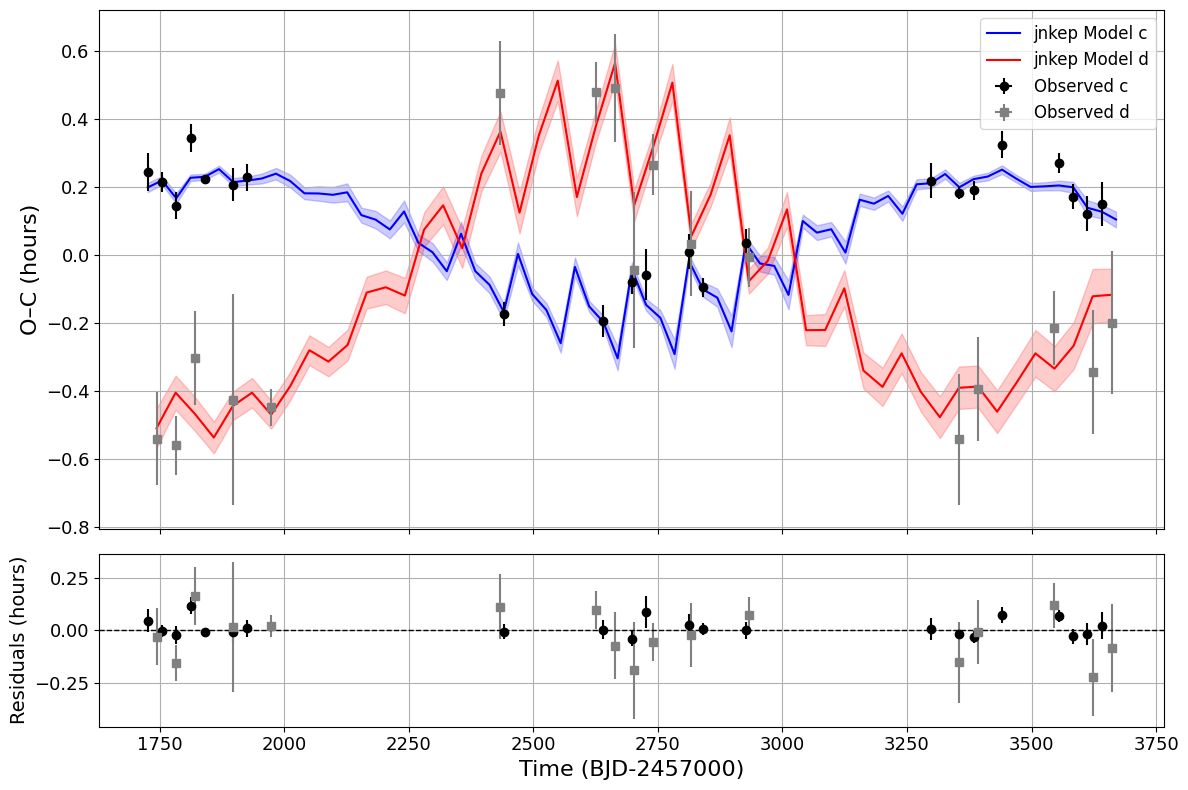

In [24]:
# Set up 2 subplots: main plot and residuals plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

### MAIN PLOT — Flattened Model and Observations
# Planet c model
ax1.plot(t_jnkep_c, (flat_jnkep_c*24)+0.2, label='jnkep Model c', color='b')
ax1.fill_between(t_jnkep_c,
                 ((flat_jnkep_c - t_jnkep_err_c)*24)+0.2,
                 ((flat_jnkep_c + t_jnkep_err_c)*24)+0.2,
                 color='b', alpha=0.2)

# Planet d model
ax1.plot(t_jnkep_d, (flat_jnkep_d*24)-0.5, label='jnkep Model d', color='r')
ax1.fill_between(t_jnkep_d,
                 ((flat_jnkep_d - t_jnkep_err_d)*24)-0.5,
                 ((flat_jnkep_d + t_jnkep_err_d)*24)-0.5,
                 color='r', alpha=0.2)

flat_obs_d = np.array(flat_obs_d)
t_obs_err_d = np.array(t_obs_err_d)
flat_obs_c = np.array(flat_obs_c)
t_obs_err_c = np.array(t_obs_err_c)

# Observed points with error bars
ax1.errorbar(t_obs_c, (flat_obs_c*24)+0.2, xerr=t_obs_err_c, yerr=(t_obs_err_c*24),
             marker='o', linestyle='none', label='Observed c', color='black')
ax1.errorbar(t_obs_d, (flat_obs_d*24)-0.5, xerr=t_obs_err_d, yerr=(t_obs_err_d*24),
             marker='s', linestyle='none', label='Observed d', color='grey')

# ax1.set_title('Flattened O–C', fontsize=16)
ax1.set_ylabel('O–C (hours)', fontsize=16)
# ax1.set_xlim(1850, 5500)
ax1.legend(fontsize=12)
ax1.grid(True)

### RESIDUALS PLOT — (Observed - Model)
# Interpolate model at observed points if needed
from scipy.interpolate import interp1d

# Interpolation to match observed points
model_interp_d = interp1d(t_jnkep_d, flat_jnkep_d, bounds_error=False, fill_value="extrapolate")
model_interp_c = interp1d(t_jnkep_c, flat_jnkep_c, bounds_error=False, fill_value="extrapolate")

residuals_d = flat_obs_d - model_interp_d(t_obs_d)
residuals_c = flat_obs_c - model_interp_c(t_obs_c)

# Plot residuals with error bars
ax2.errorbar(t_obs_c, residuals_c*24, xerr=t_obs_err_c, yerr=t_obs_err_c*24,
             marker='o', linestyle='none', color='black')
ax2.errorbar(t_obs_d, residuals_d*24, xerr=t_obs_err_d, yerr=t_obs_err_d*24,
             marker='s', linestyle='none', color='grey')

ax2.axhline(0, color='k', linestyle='--', linewidth=1)
ax2.set_xlabel(f'Time (BJD-{TESS_offset})', fontsize=16)
ax2.set_ylabel('Residuals (hours)', fontsize=14)
# ax2.set_xlim(1850, 5500)
# ax2.legend(fontsize=12)
ax2.grid(True)

ax1.tick_params(axis='both', labelsize=13)
ax2.tick_params(axis='both', labelsize=13)


plt.tight_layout()
plt.show()


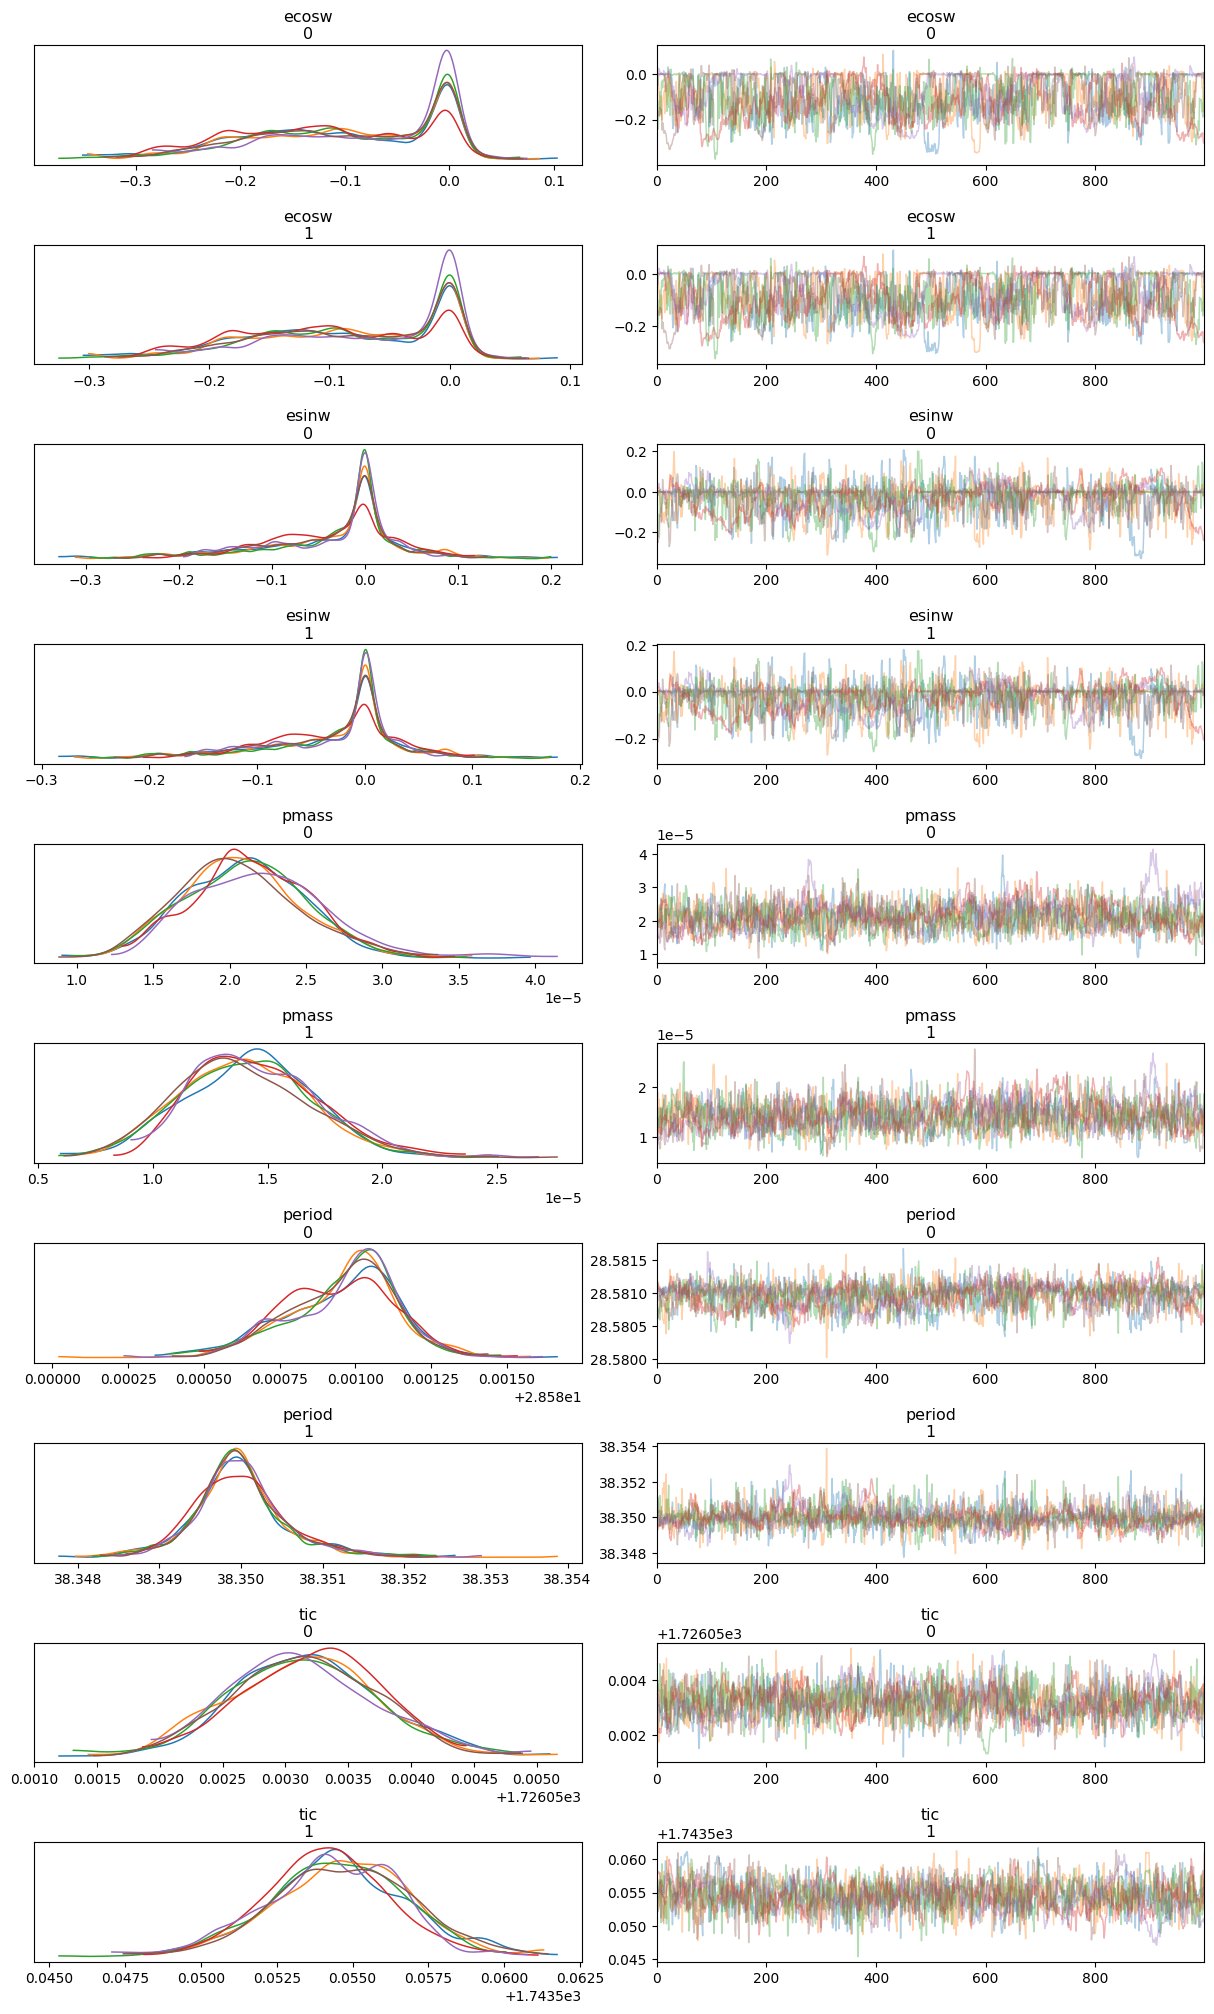

In [25]:
### remove outlie
good=[0,2,3,5,6,7]
az.summary(idata, var_names=sample_keys)
# Drop chain 1 from all groups that have 'chain' as a dimension
idata_filtered = idata.sel(chain=[c for c in idata.posterior.chain.values if c not in [1,4]])
az.plot_trace(idata_filtered, var_names=sample_keys, compact=False)
plt.tight_layout(pad=0.2)

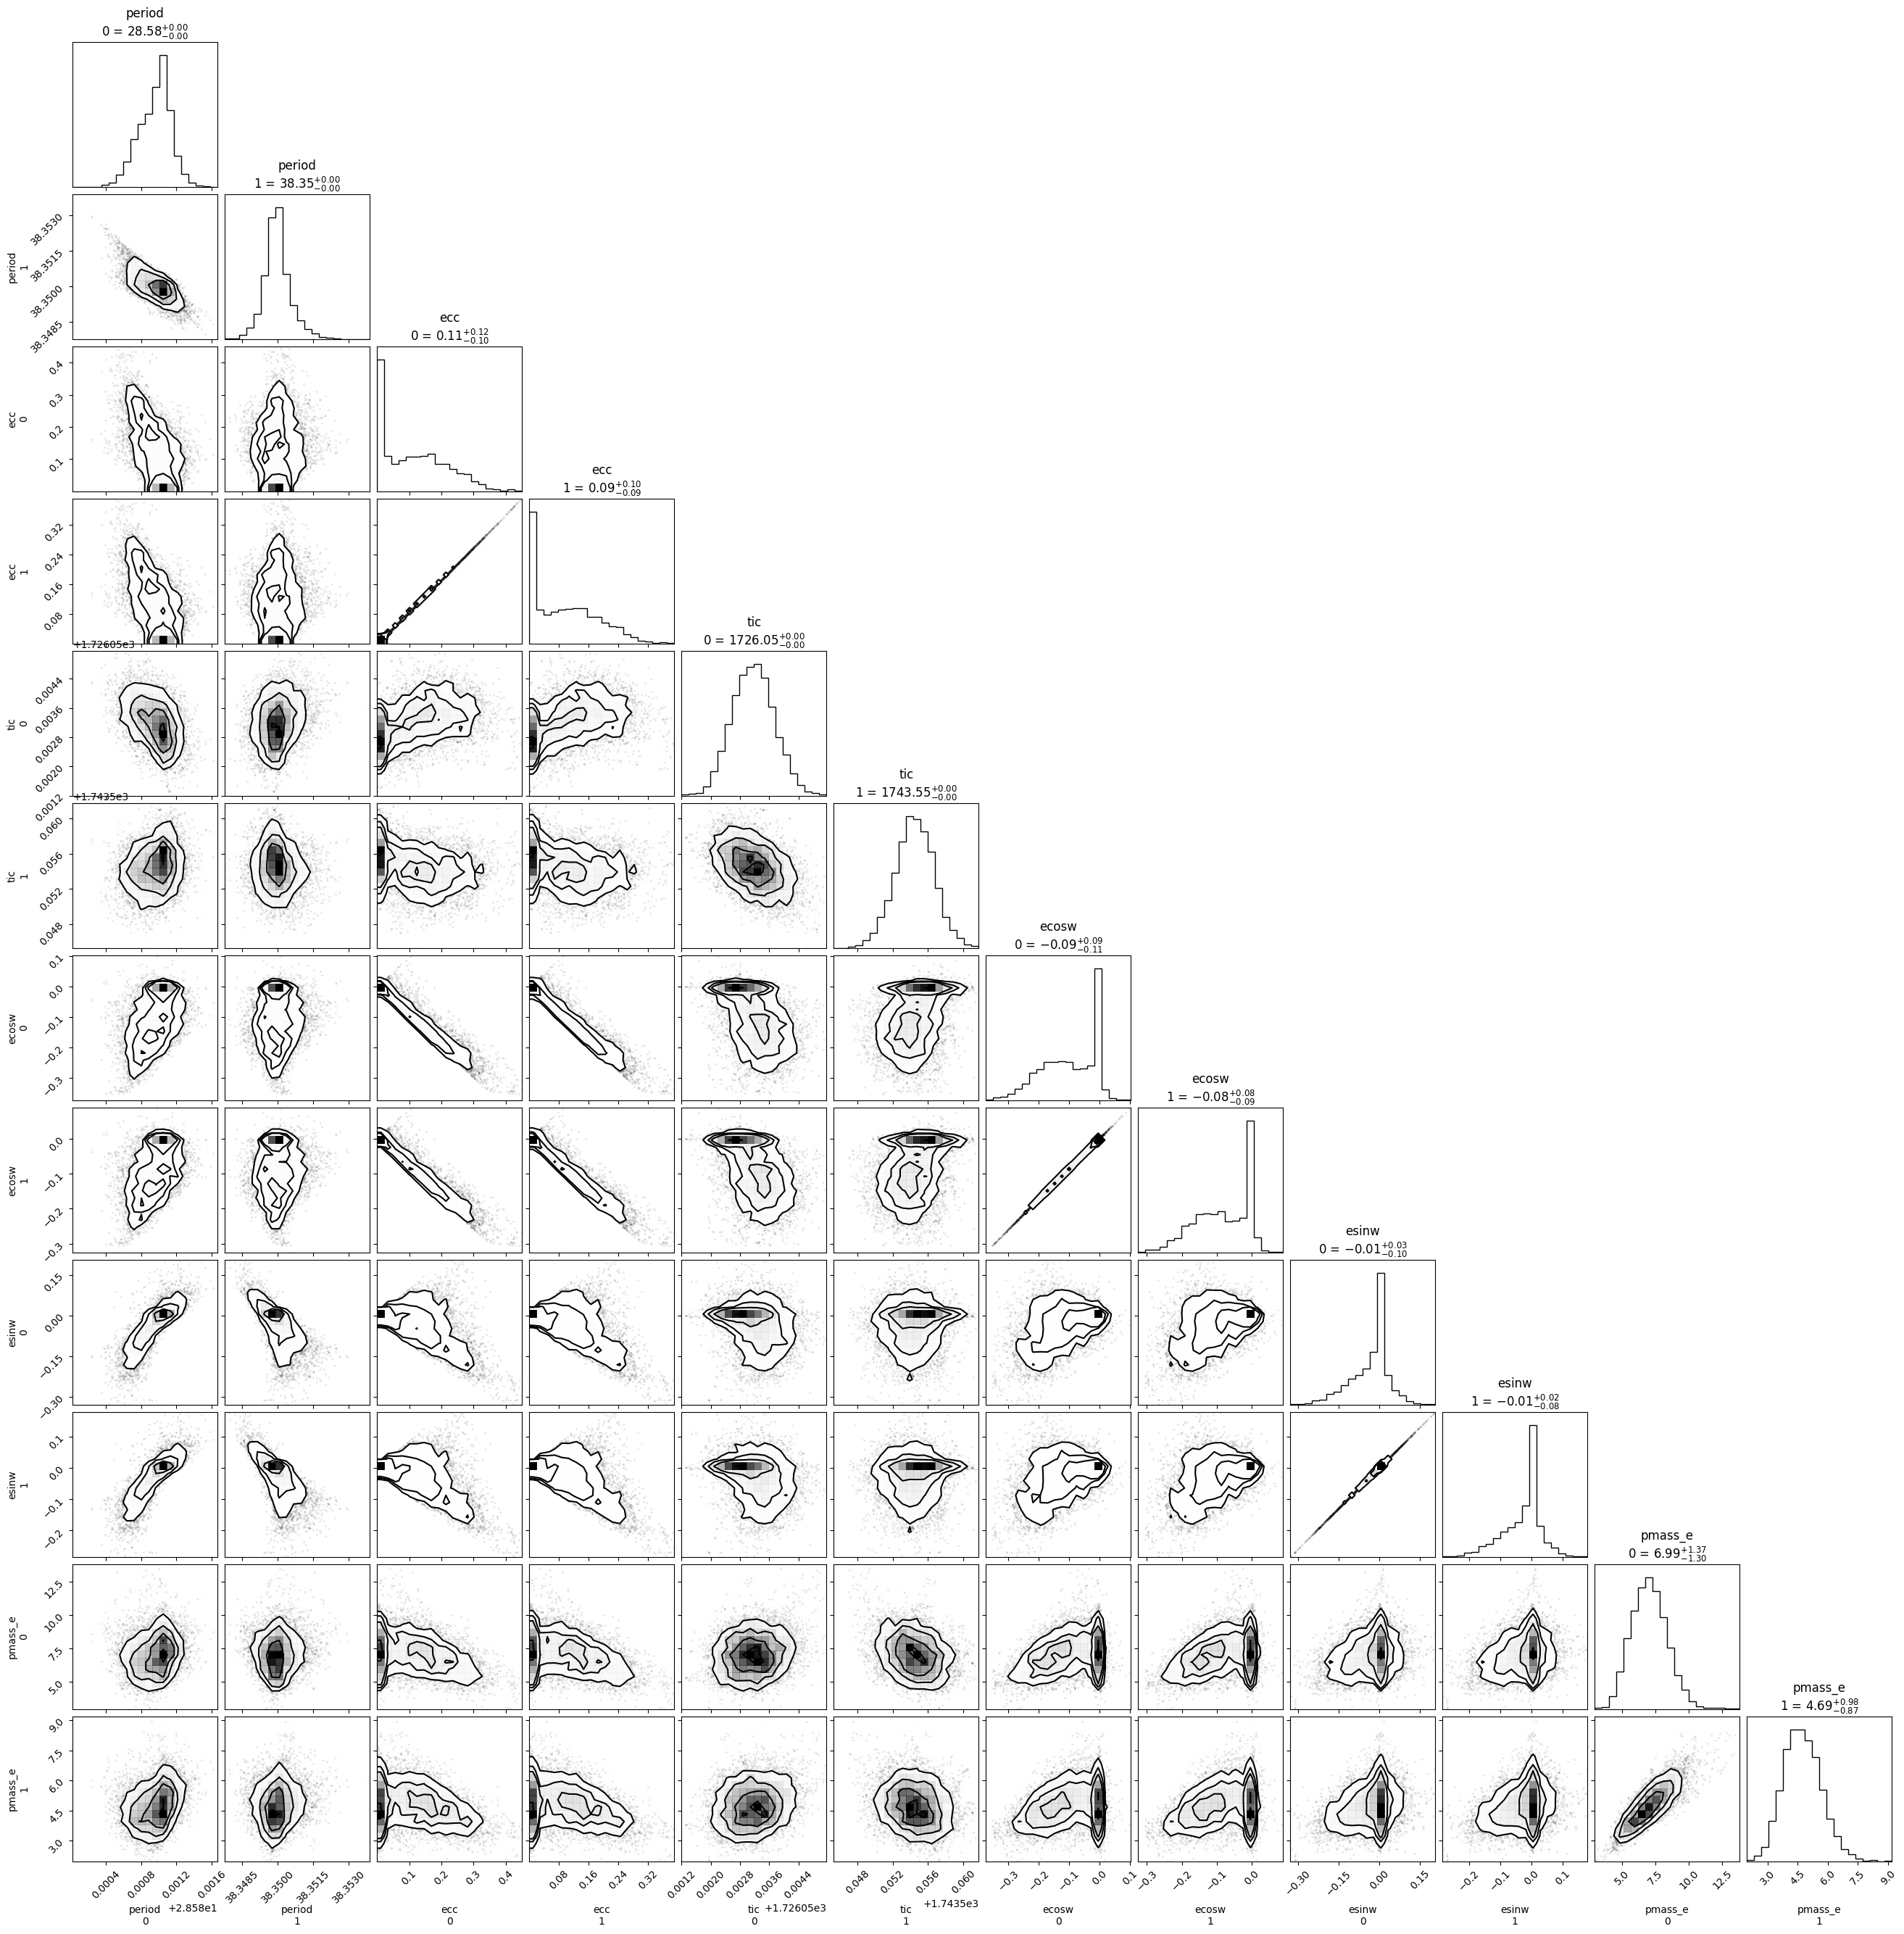

In [26]:
idata_filtered.posterior['pmass_e'] = idata_filtered.posterior['pmass'] / 3.003e-6
names = ["period", "ecc", "tic", "ecosw", "esinw", "pmass_e"]
fig = corner.corner(idata_filtered, var_names=names, show_titles=True)

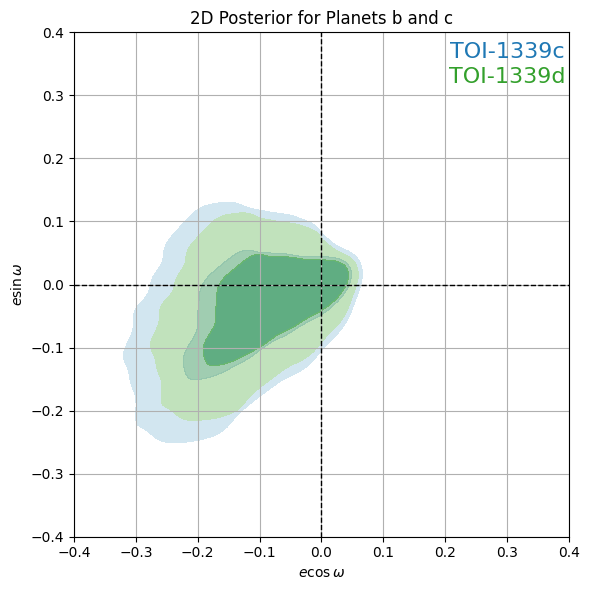

In [27]:
### 2D posterior for ecosw and esinw 
ecosw_b = samples_flat["ecosw"][:, 0]
esinw_b = samples_flat["esinw"][:, 0]

ecosw_c = samples_flat["ecosw"][:, 1]
esinw_c = samples_flat["esinw"][:, 1]

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde


def compute_kde_contour_levels(x, y, gridsize=100):
    data = np.vstack([x, y])
    kde = gaussian_kde(data)
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    X, Y = np.mgrid[x_min:x_max:gridsize*1j, y_min:y_max:gridsize*1j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kde(positions).T, X.shape)
    return X, Y, Z, kde

def get_sigma_contour_levels(Z):
    Z_flat = Z.flatten()
    Z_sorted = np.sort(Z_flat)[::-1]
    cumsum = np.cumsum(Z_sorted)
    cumsum /= cumsum[-1]
    levels = []
    for sigma in [0.683, 0.954]:
        idx = np.searchsorted(cumsum, sigma)
        levels.append(Z_sorted[idx])
    return sorted(levels)  # ensures ascending order

# Compute KDEs
Xb, Yb, Zb, kde_b = compute_kde_contour_levels(ecosw_b, esinw_b)
Xc, Yc, Zc, kde_c = compute_kde_contour_levels(ecosw_c, esinw_c)

# Get contour levels
levels_b = get_sigma_contour_levels(Zb)
levels_c = get_sigma_contour_levels(Zc)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Filled contours for planet b (blue shades)
ax.contourf(Xb, Yb, Zb, levels=levels_b + [Zb.max()], colors=['#a6cee3', '#1f78b4'], alpha=0.5)

# Filled contours for planet c (green shades)
ax.contourf(Xc, Yc, Zc, levels=levels_c + [Zc.max()], colors=['#b2df8a', '#33a02c'], alpha=0.5)

# Text annotation
ax.text(0.30, 0.36, 'TOI-1339c', color='#1f78b4', fontsize=16, ha='center')
ax.text(0.30, 0.32, 'TOI-1339d', color='#33a02c', fontsize=16, ha='center')


# Labels and legend
ax.set_xlabel(r"$e \cos\omega$")
ax.set_ylabel(r"$e \sin\omega$")
ax.set_title("2D Posterior for Planets b and c")
blue_patch = plt.Line2D([], [], color='#a6cee3', label='Planet b')
red_patch = plt.Line2D([], [], color='#b2df8a', label='Planet c')
# ax.legend(handles=[blue_patch, red_patch])
ax.axvline(x=0, linestyle='--', lw=1, color='black')
ax.axhline(y=0, linestyle='--', lw=1, color='black')

plt.grid(True)
plt.xlim(-0.40,0.40)
plt.ylim(-0.40,0.40)
plt.tight_layout()
plt.show()

In [28]:
az.summary(idata_filtered, var_names=["ecc","ecosw_scaled","esinw_scaled", "pmass_scaled","period_scaled","tic_scaled"], round_to=3)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ecc[0],0.118,0.099,0.000,0.286,0.007,0.003,224.112,615.755,1.019
ecc[1],0.101,0.085,0.000,0.246,0.006,0.002,217.632,611.908,1.020
ecosw_scaled[0],0.406,0.089,0.243,0.519,0.006,0.002,255.013,444.323,1.017
ecosw_scaled[1],0.421,0.078,0.279,0.518,0.005,0.002,249.530,451.717,1.018
esinw_scaled[0],0.471,0.073,0.316,0.596,0.004,0.003,315.783,825.402,1.019
esinw_scaled[1],0.477,0.063,0.343,0.584,0.004,0.002,316.570,822.778,1.019
pmass_scaled[0],0.021,0.004,0.013,0.028,0.000,0.000,218.364,582.836,1.025
pmass_scaled[1],0.014,0.003,0.009,0.019,0.000,0.000,275.458,936.742,1.026
period_scaled[0],0.502,0.000,0.502,0.503,0.000,0.000,290.985,1156.770,1.023
period_scaled[1],0.500,0.001,0.498,0.501,0.000,0.000,534.661,1033.381,1.012


In [29]:
remove_outlier = True

if remove_outlier:
    samples = samples_flat

# Extracting values from posteriors 

In [148]:
### posterior samples 
ecosw_c = samples["ecosw"][:, 0]
esinw_c = samples["esinw"][:, 0]
Per_c = samples["period"][:,0] # [days]
Tc_c = samples["tic"][:,0] # [days]
pmass_c = samples["pmass"][:, 0] # [solar mass]

ecosw_d = samples["ecosw"][:, 1]
esinw_d = samples["esinw"][:, 1]
Per_d = samples["period"][:,1] # [days]
Tc_d = samples["tic"][:,1] # [days]
pmass_d = samples["pmass"][:, 1] # [solar mass]

### convert planet mass from solar to earth masses 
import astropy.constants as u
convert = (u.M_sun / u.M_earth).value
pmass_earth_c = pmass_c * convert
pmass_earth_d = pmass_d * convert


# Compute eccentricity and omega (in radians and degrees) for each sample
ecc_c = np.sqrt(ecosw_c**2 + esinw_c**2)
omega_rad_c = np.arctan2(esinw_c, ecosw_c)
omega_deg_c = np.rad2deg(omega_rad_c)

# Compute eccentricity and omega (in radians and degrees) for each sample
ecc_d = np.sqrt(ecosw_d**2 + esinw_d**2)
omega_rad_d = np.arctan2(esinw_d, ecosw_d)
omega_deg_d = np.rad2deg(omega_rad_d)


### keep Omega constant
value_Omega_c = 0  # [deg]
Omega_c = [np.radians(value_Omega_c)] * len(omega_rad_c)  # [rad]
value_Omega_d = 0 # [deg]
Omega_d = [np.radians(value_Omega_d)] * len(omega_rad_d)  # [rad]

pomega_rad_c = omega_rad_c + Omega_c
pomega_rad_d = omega_rad_d + Omega_d


Delta_omega_rad = omega_rad_d - omega_rad_c
Delta_omega_deg = omega_deg_d - omega_deg_c

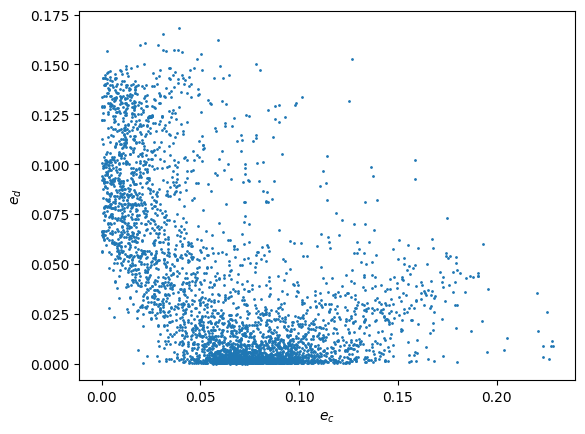

In [150]:
plt.scatter(ecc_c, ecc_d, s=1)
plt.xlabel(r"$e_c$")
plt.ylabel(r"$e_d$")
# plt.xlim(0.0, 0.2)
# plt.ylim(0.0, 0.25)
plt.show()

In [63]:
def get_median_and_1sigma(samples):
    median = np.median(samples)
    lower = np.percentile(samples, 16)
    upper = np.percentile(samples, 84)
    return median, median - lower, upper - median

def get_median_and_symmetric_1sigma(samples):
    median = np.median(samples)
    lower = np.percentile(samples, 16)
    upper = np.percentile(samples, 84)
    sigma = 0.5 * (upper - lower)  # symmetric 1σ
    return median, sigma

### Asymmetric errors

In [64]:
# Planet c
Per_c_med, Per_c_lo, Per_c_hi = get_median_and_1sigma(Per_c)
Tc_c_med, Tc_c_lo, Tc_c_hi = get_median_and_1sigma(Tc_c)
esinw_c_med, esinw_c_lo, esinw_c_hi = get_median_and_1sigma(esinw_c)
ecosw_c_med, ecosw_c_lo, ecosw_c_hi = get_median_and_1sigma(ecosw_c)
ecc_c_median, ecc_c_lo, ecc_c_hi = get_median_and_1sigma(ecc_c)
omega_deg_c_median, omega_deg_c_lo, omega_deg_c_hi = get_median_and_1sigma(omega_deg_c)
pmass_earth_c_median, pmass_earth_c_lo, pmass_earth_c_hi = get_median_and_1sigma(pmass_earth_c)

# Planet 
Per_d_med, Per_d_lo, Per_d_hi = get_median_and_1sigma(Per_d)
Tc_d_med, Tc_d_lo, Tc_d_hi = get_median_and_1sigma(Tc_d)
esinw_d_med, esinw_d_lo, esinw_d_hi = get_median_and_1sigma(esinw_d)
ecosw_d_med, ecosw_d_lo, ecosw_d_hi = get_median_and_1sigma(ecosw_d)
ecc_d_median, ecc_d_lo, ecc_d_hi = get_median_and_1sigma(ecc_d)
omega_deg_d_median, omega_deg_d_lo, omega_deg_d_hi = get_median_and_1sigma(omega_deg_d)
pmass_earth_d_median, pmass_earth_d_lo, pmass_earth_d_hi = get_median_and_1sigma(pmass_earth_d)

# Difference in omega
Delta_omega_deg_median, Delta_omega_deg_lo, Delta_omega_deg_hi = get_median_and_1sigma(Delta_omega_deg)


In [65]:
print(f"Period_c = {Per_c_med:.5f} (+{Per_c_hi:.5f}/-{Per_c_lo:.5f}) days")
print(f"Tc_c = {Tc_c_med:.5f} (+{Tc_c_hi:.5f}/-{Tc_c_lo:.5f}) days")
print(f"esinω_c = {esinw_c_med:.4f} (+{esinw_c_hi:.4f}/-{esinw_c_lo:.4f})")
print(f"ecosω_c = {ecosw_c_med:.4f} (+{ecosw_c_hi:.4f}/-{ecosw_c_lo:.4f})")
print(f"Ecc_c = {ecc_c_median:.3f} (+{ecc_c_hi:.3f}/-{ecc_c_lo:.3f})")
print(f"ω_c (deg) = {omega_deg_c_median:.1f} (+{omega_deg_c_hi:.1f}/-{omega_deg_c_lo:.1f})")
print(f"Mass_c (Earth) = {pmass_earth_c_median:.2f} (+{pmass_earth_c_hi:.2f}/-{pmass_earth_c_lo:.2f})")
print('\n')

print(f"Period_d = {Per_d_med:.5f} (+{Per_d_hi:.5f}/-{Per_d_lo:.5f}) days")
print(f"Tc_d = {Tc_d_med:.5f} (+{Tc_d_hi:.5f}/-{Tc_d_lo:.5f}) days")
print(f"esinω_d = {esinw_d_med:.4f} (+{esinw_d_hi:.4f}/-{esinw_d_lo:.4f})")
print(f"ecosω_d = {ecosw_d_med:.4f} (+{ecosw_d_hi:.4f}/-{ecosw_d_lo:.4f})")
print(f"Ecc_d = {ecc_d_median:.3f} (+{ecc_d_hi:.3f}/-{ecc_d_lo:.3f})")
print(f"ω_d (deg) = {omega_deg_d_median:.1f} (+{omega_deg_d_hi:.1f}/-{omega_deg_c_lo:.1f})")
print(f"Mass_d (Earth) = {pmass_earth_d_median:.2f} (+{pmass_earth_d_hi:.2f}/-{pmass_earth_d_lo:.2f})")
print('\n')

print(f"Δω (deg) = {Delta_omega_deg_median:.1f} (+{Delta_omega_deg_hi:.1f}/-{Delta_omega_deg_lo:.1f})")


Period_c = 28.58098 (+0.00013/-0.00022) days
Tc_c = 1726.05316 (+0.00057/-0.00057) days
esinω_c = -0.0089 (+0.0266/-0.0967)
ecosω_c = -0.0916 (+0.0899/-0.1055)
Ecc_c = 0.108 (+0.119/-0.101)
ω_c (deg) = -130.9 (+287.5/-31.4)
Mass_c (Earth) = 6.99 (+1.37/-1.30)


Period_d = 38.34995 (+0.00053/-0.00045) days
Tc_d = 1743.55448 (+0.00218/-0.00216) days
esinω_d = -0.0066 (+0.0227/-0.0833)
ecosω_d = -0.0767 (+0.0769/-0.0922)
Ecc_d = 0.091 (+0.103/-0.086)
ω_d (deg) = -119.7 (+273.2/-31.4)
Mass_d (Earth) = 4.69 (+0.98/-0.87)


Δω (deg) = -0.2 (+3.0/-1.5)


### Symmetric errors

In [115]:
# Planet c
Per_c_med, Per_c_err = get_median_and_symmetric_1sigma(Per_c)
Tc_c_med, Tc_c_err = get_median_and_symmetric_1sigma(Tc_c)
esinw_c_med, esinw_c_err = get_median_and_symmetric_1sigma(esinw_c)
ecosw_c_med, ecosw_c_err = get_median_and_symmetric_1sigma(ecosw_c)
ecc_c_median, ecc_c_err = get_median_and_symmetric_1sigma(ecc_c)
omega_deg_c_median, omega_deg_c_err = get_median_and_symmetric_1sigma(omega_deg_c)
pmass_earth_c_median, pmass_earth_c_err = get_median_and_symmetric_1sigma(pmass_earth_c)

# Planet 
Per_d_med, Per_d_err = get_median_and_symmetric_1sigma(Per_d)
Tc_d_med, Tc_d_err = get_median_and_symmetric_1sigma(Tc_d)
esinw_d_med, esinw_d_err = get_median_and_symmetric_1sigma(esinw_d)
ecosw_d_med, ecosw_d_err = get_median_and_symmetric_1sigma(ecosw_d)
ecc_d_median, ecc_d_err = get_median_and_symmetric_1sigma(ecc_d)
omega_deg_d_median, omega_deg_d_err = get_median_and_symmetric_1sigma(omega_deg_d)
pmass_earth_d_median, pmass_earth_d_err = get_median_and_symmetric_1sigma(pmass_earth_d)

# Difference in omega
Delta_omega_deg_median, Delta_omega_deg_err = get_median_and_symmetric_1sigma(Delta_omega_deg)


In [116]:
print(f"Period_c = {Per_c_med:.5f} (+-{Per_c_err:.5f}) days")
print(f"Tc_c = {Tc_c_med:.5f} (+-{Tc_c_err:.5f}) days")
print(f"esinω_c = {esinw_c_med:.4f} (+-{esinw_c_err:.4f})")
print(f"ecosω_c = {ecosw_c_med:.4f} (+-{ecosw_c_err:.4f})")
print(f"Ecc_c = {ecc_c_median:.3f} (+-{ecc_c_err:.3f}")
print(f"ω_c (deg) = {omega_deg_c_median:.1f} (+-{omega_deg_c_err:.1f})")
print(f"Mass_c (Earth) = {pmass_earth_c_median:.2f} (+-{pmass_earth_c_err:.2f})")
print('\n')

print(f"Period_d = {Per_d_med:.5f} (+-{Per_d_err:.5f}) days")
print(f"Tc_d = {Tc_d_med:.5f} (+-{Tc_d_err:.5f}) days")
print(f"esinω_d = {esinw_d_med:.4f} (+-{esinw_d_err:.4f})")
print(f"ecosω_d = {ecosw_d_med:.4f} (+-{ecosw_d_err:.4f})")
print(f"Ecc_d = {ecc_d_median:.3f} (+-{ecc_d_err:.3f})")
print(f"ω_d (deg) = {omega_deg_d_median:.1f} (+-{omega_deg_d_err:.1f})")
print(f"Mass_d (Earth) = {pmass_earth_d_median:.2f} (+-{pmass_earth_d_err:.2f})")
print('\n')

print(f"Δω (deg) = {Delta_omega_deg_median:.1f} (+-{Delta_omega_deg_err:.1f})")


Period_c = 28.58098 (+-0.00018) days
Tc_c = 1726.05316 (+-0.00057) days
esinω_c = -0.0089 (+-0.0616)
ecosω_c = -0.0916 (+-0.0977)
Ecc_c = 0.108 (+-0.110
ω_c (deg) = -130.9 (+-159.4)
Mass_c (Earth) = 6.99 (+-1.33)


Period_d = 38.34995 (+-0.00049) days
Tc_d = 1743.55448 (+-0.00217) days
esinω_d = -0.0066 (+-0.0530)
ecosω_d = -0.0767 (+-0.0845)
Ecc_d = 0.091 (+-0.095)
ω_d (deg) = -119.7 (+-157.1)
Mass_d (Earth) = 4.69 (+-0.93)


Δω (deg) = -0.2 (+-2.2)


In [104]:
def resonant_bandwidth(j, m1, m2, m_star):
    term1 = (j-1) / j**(2./3.)
    term2 = ((m1+m2) / m_star)**(2./3.)
    res_bw = 5*term1*term2
    return res_bw *100 # percents

m_star = 0.81 # [solar mass]

res_bw = resonant_bandwidth(4, pmass_d, pmass_c, m_star)

res_bw_med, res_bw_err = get_median_and_symmetric_1sigma(res_bw)
print(f"Resonant bw = {res_bw_med:.4f} (+-{res_bw_hi:.4f})")

Resonant bw = 0.7361 (+-0.0894)


In [103]:
def delta_chi_2017(j, m1, m2, m_star):
    term1 = j**(1./3.)
    term2 = ((m1+m2) / m_star)**(2./3.)
    res_bw = 5*term1*term2
    return res_bw *100 # percents

delta_chi = delta_chi_2017(4, pmass_d, pmass_c, m_star)
delta_chi_med, delta_chi_err = get_median_and_symmetric_1sigma(delta_chi)
print(f"Delta chi = {delta_chi_med:.4f} (+-{delta_chi_err:.4f})")



Delta chi = 0.9815 (+-0.1222)


In [68]:
def delta_res(P1, P2, j):
    term1 = P2 / P1
    term2 = ((j-1)/j)
    delta = (term1*term2) - 1
    return delta  # percents

delta = delta_res(Per_c, Per_d, 4)

delta_med, delta_hi, delta_lo = get_median_and_1sigma(delta)
print(f"Delta res = {delta_med:.4f} (+{delta_hi:.4f}/-{delta_lo:.4f})")


Delta res = 0.0063 (+0.0000/-0.0000)


In [78]:
def ttv_per(P2, j, delta):
    P12 = P2 / (j*np.abs(delta))
    return P12

ttv_period = ttv_per(Per_d, 4, delta)
# ttv_per_med, ttv_per_hi, ttv_per_lo = get_median_and_1sigma(ttv_period)
# print(f"TTV period = {ttv_per_med:.4f} (+{ttv_per_hi:.4f}/-{ttv_per_lo:.4f})")
ttv_per_med, ttv_per_err = get_median_and_symmetric_1sigma(ttv_period)
print(f"TTV period = {ttv_per_med:.4f} (+-{ttv_per_err:.4f})")

delta_percent = delta*100
# delta_percent_med, delta_percent_hi, delta_percent_lo = get_median_and_1sigma(delta_percent)
# print(f"Delta res = {delta_percent_med:.4f} (+{delta_percent_hi:.4f}/-{delta_percent_lo:.4f})")

delta_percent_med, delta_percent_err = get_median_and_symmetric_1sigma(delta_percent)
print(f"Delta res = {delta_percent_med:.4f} (+-{delta_percent_err:.4f})")


TTV period = 1509.9055 (+-4.1383)
Delta res = 0.6350 (+-0.0017)


# Save for paper

In [117]:
Per_c_med = round(Per_c_med, 4)
Per_c_hi = round(Per_c_hi, 4)
Per_c_lo = round(Per_c_lo, 4)
Per_c_err = round(Per_c_err, 4)

Tc_c_med = round(Tc_c_med, 4)
Tc_c_hi = round(Tc_c_hi, 4)
Tc_c_lo = round(Tc_c_lo, 4)
Tc_c_err = round(Tc_c_err, 4)

esinw_c_med = round(esinw_c_med, 2)
esinw_c_hi = round(esinw_c_hi, 2)
esinw_c_lo = round(esinw_c_lo, 2)
esinw_c_err = round(esinw_c_err, 2)

ecosw_c_med = round(ecosw_c_med, 2)
ecosw_c_hi = round(ecosw_c_hi, 2)
ecosw_c_lo = round(ecosw_c_lo, 2)
ecosw_c_err = round(ecosw_c_err, 2)

ecc_c_median = round(ecc_c_median, 2)
ecc_c_hi = round(ecc_c_hi,2)
ecc_c_lo = round(ecc_c_lo,2)
ecc_c_err = round(ecc_c_err,2)

omega_deg_c_median = round(omega_deg_c_median, 2)
omega_deg_c_hi = round(omega_deg_c_hi, 2)
omega_deg_c_lo = round(omega_deg_c_lo, 2)
omega_deg_c_err = round(omega_deg_c_err, 2)

pmass_earth_c_median = round(pmass_earth_c_median, 1)
pmass_earth_c_hi = round(pmass_earth_c_hi, 1)
pmass_earth_c_lo = round(pmass_earth_c_lo, 1)
pmass_earth_c_err = round(pmass_earth_c_err, 1)

###

Per_d_med = round(Per_d_med, 4)
Per_d_hi = round(Per_d_hi, 4)
Per_d_lo = round(Per_d_lo, 4)
Per_d_err = round(Per_d_err, 4)

Tc_d_med = round(Tc_d_med, 4)
Tc_d_hi = round(Tc_d_hi, 4)
Tc_d_lo = round(Tc_d_lo, 4)
Tc_d_err = round(Tc_d_err, 4)

esinw_d_med = round(esinw_d_med, 2)
esinw_d_hi = round(esinw_d_hi, 2)
esinw_d_lo = round(esinw_d_lo, 2)
esinw_d_err = round(esinw_d_err, 2)

ecosw_d_med = round(ecosw_d_med, 2)
ecosw_d_hi = round(ecosw_d_hi, 2)
ecosw_d_lo = round(ecosw_d_lo, 2)
ecosw_d_err = round(ecosw_d_err, 2)

ecc_d_median = round(ecc_d_median, 2)
ecc_d_hi = round(ecc_d_hi,2)
ecc_d_lo = round(ecc_d_lo,2)
ecc_d_err = round(ecc_d_err,2)

omega_deg_d_median = round(omega_deg_d_median, 2)
omega_deg_d_hi = round(omega_deg_d_hi, 2)
omega_deg_d_lo = round(omega_deg_d_lo, 2)
omega_deg_d_err = round(omega_deg_d_err, 2)

pmass_earth_d_median = round(pmass_earth_d_median, 1)
pmass_earth_d_hi = round(pmass_earth_d_hi, 1)
pmass_earth_d_lo = round(pmass_earth_d_lo, 1)
pmass_earth_d_err = round(pmass_earth_d_err, 1)


Delta_omega_deg_median = round(Delta_omega_deg_median, 1)
Delta_omega_deg_hi = round(Delta_omega_deg_hi, 1)
Delta_omega_deg_lo = round(Delta_omega_deg_lo, 1)
Delta_omega_deg_err = round(Delta_omega_deg_err, 1)



###
delta_percent_med = round(delta_percent_med, 4)
delta_percent_err = round(delta_percent_err, 4)
ttv_per_med = round(ttv_per_med, 1)
ttv_per_err = round(ttv_per_err, 1)
delta_chi_med = round(delta_chi_med, 4)
delta_chi_err = round(delta_chi_err, 4)
res_bw_med = round(res_bw_med, 4)
res_bw_err = round(res_bw_err, 4)

In [118]:
### sourced from literature 
# stellar - lubin 2024
mstar_val, mstar_err = 0.81, 0.04
rstar_val, rstar_err = 0.94, 0.02
teff_val, teff_err = 5348, 100 # [K]
logg_val, logg_err = 4.3, 0.1 # [dex]
metallicity_val, metallicity_err = -0.15, 0.06 # [dex]


# q1_val, q1_err = 0.4, 0.1
# q2_val, q2_err = 0.3, 0.2
# from ldtk
u1_tess_val, u1_tess_err = 0.4422, 0.0018
u2_tess_val, u2_tess_err = 0.1470, 0.0029
### 1=c 2=d, orell-mmiquel
inc1_val, inc1_err_hi, inc1_err_lo = 89.10, 0.06, 0.08
inc2_val, inc2_err_hi, inc2_err_lo = 89.49, 0.05, 0.08

ror1_val, ror1_err_hi, ror1_err_lo = 0.03118, 0.00027, 0.00034
ror2_val, ror2_err_hi, ror2_err_lo = 0.02916, 0.00034, 0.00021

b1_val, b1_err_hi, b1_err_lo = 0.630, 0.050, 0.030
b2_val, b2_err_hi, b2_err_lo = 0.440, 0.050, 0.030

T14_1_val, T14_1_err_hi, T14_1_err_lo = 4.162, 0.240, 0.096 # hours, 
T14_2_val, T14_2_err_hi, T14_2_err_lo = 5.36, 0.19, 0.11

from astropy.constants import R_earth, R_sun, M_earth, M_sun
# rade1_val = ror1_value * rstar_val * (R_earth/R_sun)
# from orell miquel
rade1_val, rade1_err = 3.195, 0.075
rade2_val, rade2_err = 2.995, 0.070



### planet b params from literature as of now 
masse_b, masse_b_err = 10.00, 0.70
rade_b, rade_b_err = 3.410, 0.075
Per_b, Per_b_err = 8.8803256, 0.0000047

## calculate density

In [119]:
### bulk density 
def bulk_density(mass, radius, sigma_mass, sigma_radius):
    volume = (4./3.) * np.pi * radius**3   # assuming spherical 
    rho = mass / volume

    frac_err_mass = sigma_mass / mass
    frac_err_radius = sigma_radius / radius
    # error propagation: (σρ/ρ)^2 = (σM/M)^2 + 9 (σR/R)^2
    frac_err_rho = np.sqrt(frac_err_mass**2 + 9 * frac_err_radius**2)
    sigma_rho = rho * frac_err_rho
    # convert to g/cm^3
    conversion = (1000 / (100**3))
    return rho*conversion, sigma_rho*conversion

mass_b = masse_b * M_earth.value 
sigma_m_b = masse_b_err * M_earth.value 
rad_b = rade_b * R_earth.value
sigma_rad_b = rade_b_err * R_earth.value

# print(bulk_density(4.09 * M_earth.value ,2.62 * R_earth.value,0.4 * M_earth.value ,0.11 * R_earth.value))

rho_b, rho_err_b = bulk_density(mass_b, rad_b, sigma_m_b, sigma_rad_b)
print(rho_b, rho_err_b)

1.3858182870227351 0.13331022861431654


In [120]:
def bulk_density_asym_log(mass_med, mass_lo, mass_hi,
                          radius_med, radius_err):
    """
    Compute bulk density and asymmetric 1-sigma errors using log-space propagation.
    mass_med, mass_lo, mass_hi: median and +/-1sigma offsets for mass (mass_lo/mass_hi > 0)
        interpreted such that mass_low_val = mass_med - mass_lo, mass_high_val = mass_med + mass_hi.
    radius_med, radius_err: median and symmetric 1sigma for radius (radius_err > 0)
    Units: by default inputs are in Earth units; set mass_in_earth or radius_in_earth False if already SI.

    Returns:
      rho_med, rho_err_lo, rho_err_hi, rho_med_gcm3, rho_err_lo_gcm3, rho_err_hi_gcm3
      where rho_err_lo = rho_med - rho_lower (positive), rho_err_hi = rho_upper - rho_med (positive).
    """

    M_med = mass_med * M_earth.value
    M_low_val = (mass_med - mass_lo) * M_earth.value
    M_high_val = (mass_med + mass_hi) * M_earth.value
    

    R_med = radius_med * R_earth.value
    R_low_val = (radius_med - radius_err) * R_earth.value
    R_high_val = (radius_med + radius_err) * R_earth.value
    
    # Basic checks
    if M_low_val <= 0 or R_low_val <= 0:
        raise ValueError("Lower bound on mass or radius is non-physical (<= 0). Use a posterior/sampling method.")

    # median density
    rho_med = M_med / ((4.0/3.0) * np.pi * R_med**3)

    # Convert asymmetric mass errors to log-space sigmas:
    lnM_med = np.log(M_med)
    lnM_low  = np.log(M_low_val)
    lnM_high = np.log(M_high_val)
    sigma_lnM_lo = lnM_med - lnM_low   # positive
    sigma_lnM_hi = lnM_high - lnM_med  # positive

    # Convert symmetric radius error to log-space sigma (use exact ln form)
    lnR_med = np.log(R_med)
    lnR_high = np.log(R_high_val)
    # radius error is symmetric so sigma_lnR (use + side)
    sigma_lnR = lnR_high - lnR_med     # positive

    # Propagate in log-space: ln rho = ln M - 3 ln R
    sigma_lnrho_lo = np.sqrt(sigma_lnM_lo**2 + (3.0 * sigma_lnR)**2)
    sigma_lnrho_hi = np.sqrt(sigma_lnM_hi**2 + (3.0 * sigma_lnR)**2)

    # Convert back to linear space: multiplicative factors
    rho_low  = rho_med * np.exp(-sigma_lnrho_lo)
    rho_high = rho_med * np.exp( sigma_lnrho_hi)

    rho_err_lo = rho_med - rho_low   # positive
    rho_err_hi = rho_high - rho_med  # positive

    # also return in g/cm^3
    rho_med_g = rho_med * 1e-3
    rho_err_lo_g = rho_err_lo * 1e-3
    rho_err_hi_g = rho_err_hi * 1e-3

    return (rho_med_g, rho_err_lo_g, rho_err_hi_g)



rho_med_c, rho_err_lo_c, rho_err_hi_c = bulk_density_asym_log(pmass_earth_c_median, pmass_earth_c_lo, pmass_earth_c_hi, rade1_val, rade1_err)
print(f"rho = {rho_med_c:.3f} -{rho_err_lo_c:.3f} +{rho_err_hi_c:.3f} g/cm^3")
rho_err_c = (rho_err_hi_c + rho_err_lo_c) / 2
print(f"rho = {rho_med_c:.3f} +-{rho_err_c:.3f} g/cm^3")

rho_med_d, rho_err_lo_d, rho_err_hi_d = bulk_density_asym_log(pmass_earth_d_median, pmass_earth_d_lo, pmass_earth_d_hi, rade2_val, rade2_err)
print(f"rho = {rho_med_d:.3f} -{rho_err_lo_d:.3f} +{rho_err_hi_d:.3f} g/cm^3")
rho_err_d = (rho_err_hi_d + rho_err_lo_d) / 2
print(f"rho = {rho_med_d:.3f} +-{rho_err_d:.3f} g/cm^3")

rho = 1.179 -0.230 +0.254 g/cm^3
rho = 1.179 +-0.242 g/cm^3
rho = 0.961 -0.193 +0.219 g/cm^3
rho = 0.961 +-0.206 g/cm^3


## Calculate TSM

In [121]:
### tramsission spectroscopy metric TSM
def TSM_(scale_factor, radius_p, mass_p, radius_star, T_eq, m_j):
    term_num = (radius_p**3) * T_eq
    term_den = mass_p * (radius_star**2)
    term1 = term_num / term_den
    term2 = 10**(-m_j/5)
    TSM = scale_factor * term1 * term2
    return TSM

def T_equilibrium(r_star, T_star, a_planet):
    term1 = np.sqrt(r_star/a_planet)
    term2 = (1./4.)**(1./4.)
    T_eq = T_star * term1 * term2
    return T_eq

scale_factor = 1.28 # kempton 2018

T_star = 5348
r_star = 0.94
m_j = 7.597
from astropy import units as u
from astropy import constants as c
G_const_si = c.G
G_const = c.G.to(u.R_sun**3 / u.M_sun / u.day**2).value
print(G_const)

a_b = ((G_const*m_star*Per_b**2)/(4*np.pi**2))**(1.0/3.)
a_c = ((G_const*m_star*Per_c_med**2)/(4*np.pi**2))**(1.0/3.)
a_d = ((G_const*m_star*Per_d_med**2)/(4*np.pi**2))**(1.0/3.)

T_eq_b = T_equilibrium(r_star, T_star, a_b)
T_eq_c = T_equilibrium(r_star, T_star, a_c)
T_eq_d = T_equilibrium(r_star, T_star, a_d)

TSM_b = int(TSM_(scale_factor, rade_b, masse_b, r_star, T_eq_b, m_j))
TSM_c = int(TSM_(scale_factor, rade1_val, pmass_earth_c_median, r_star, T_eq_c, m_j))
TSM_d = int(TSM_(scale_factor, rade2_val, pmass_earth_d_median, r_star, T_eq_d, m_j))

print(TSM_b)
print(TSM_c)
print(TSM_d)

2942.2062175044193
155
123
137


## read in table 3 fenv model

In [122]:
lopez = False

In [123]:
if lopez: 
    df_100myr = pd.read_csv(
        'data/model_table_100myr.txt',
        sep=r'\s+',         # regex for 1+ spaces
        skiprows=3,         # adjust to skip header/title lines
        engine='python'     # sometimes needed for regex separator
    )
    
    df_1gyr = pd.read_csv(
        'data/model_table_1gyr.txt',
        sep=r'\s+',         # regex for 1+ spaces
        skiprows=3,         # adjust to skip header/title lines
        engine='python'     # sometimes needed for regex separator
    )
    
    df_10gyr = pd.read_csv(
        'data/model_table_10gyr.txt',
        sep=r'\s+',         # regex for 1+ spaces
        skiprows=3,         # adjust to skip header/title lines
        engine='python'     # sometimes needed for regex separator
    )
    # print(df_10gyr)
    
    ages = np.array([0.1, 1.0, 10.0]) # in Gyr

else:
    df_10myr = pd.read_csv("data/20mbar_10Myr_1x.csv", comment='#')
    df_100myr = pd.read_csv("data/20mbar_100Myr_1x.csv", comment='#')
    df_1gyr = pd.read_csv("data/20mbar_1Gyr_1x.csv", comment='#')
    df_10gyr = pd.read_csv("data/20mbar_10Gyr_1x.csv", comment='#')
    
    ages = np.array([0.01, 0.1, 1, 10]) # in Gyr

In [124]:
fenv_cols = df_10gyr.columns[2:]
print(fenv_cols)

# envelope fractions as decimals 
f_envs = np.array([float(c.replace('%', ''))/100 for c in fenv_cols])

Index(['0.10%', '0.20%', '0.50%', '1%', '2%', '5%', '10%', '20%'], dtype='object')


In [125]:
### mass and flux values same for three models 
if lopez:
    flux_array = df_10gyr['Flux(F_oplus)'].values
    mass_array = df_10gyr['Mass(M_oplus)'].values
else: 
    flux_array = df_10gyr['flux (F_e)'].values
    mass_array = df_10gyr['core mass (M_e)'].values
fluxes = np.sort(np.unique(flux_array))
masses = np.sort(np.unique(mass_array))


In [126]:
radii_table = np.zeros((len(ages), len(fluxes),len(masses), len(f_envs)))
if lopez:
    dataframes = [df_100myr, df_1gyr, df_10gyr]
else: 
    dataframes = [df_10myr, df_100myr, df_1gyr, df_10gyr]
for k, df in enumerate(dataframes):
    for i, F in enumerate(fluxes):
        for j, M in enumerate(masses):
            idx = np.where((flux_array == F) & (mass_array == M))[0][0]
            radii_table[k, i, j, :] = df.loc[idx, fenv_cols].values


In [127]:
print("radii_table shape:", radii_table.shape)
# print("fluxes:", fluxes)
# print("masses:", masses)
# print("f_envs:", f_envs)
# print(radii_table)

radii_table shape: (4, 4, 11, 8)


In [128]:
def sample_asymmetric_normal(median, lo, hi, nsamp=10000):
    """
    Sample from a split-normal (two-piece normal) distribution defined
    by median, lower bound (lo), and upper bound (hi).
    Here lo and hi are the 1-sigma distances: median - lo_val, hi_val - median.
    If lo==hi (or one is None), falls back to symmetric normal.
    
    Parameters
    ----------
    median : float
        central value
    lo : float
        lower 1-sigma bound (value < median) OR absolute sigma_left (positive)
        If given as the upper bound value, the function expects the caller to pass
        the lower sigma = median - lo_value. (See usage below.)
    hi : float
        upper 1-sigma bound (value > median) OR absolute sigma_right (positive)
    nsamp : int
        number of samples
    Returns
    -------
    samples : ndarray (nsamp,)
    """
    # Interpret arguments: if lo < median and hi > median assume they are values, convert
    # to sigmas: sigma_left = median - lo, sigma_right = hi - median
    sigma_left = None
    sigma_right = None
    if (lo is not None) and (hi is not None) and (lo < median < hi):
        sigma_left = median - lo
        sigma_right = hi - median
    else:
        # assume lo and hi are sigmas already (positive)
        if lo is None and hi is None:
            raise ValueError("Provide either (lo_value, hi_value) or (sigma_left, sigma_right).")
        sigma_left = float(lo) if lo is not None else float(hi)
        sigma_right = float(hi) if hi is not None else float(lo)

    # if sigmas are (nearly) equal, do symmetric normal
    if np.isclose(sigma_left, sigma_right):
        return np.random.normal(loc=median, scale=sigma_left, size=nsamp)

    # split-normal: draw standard normal z; scale negative z by sigma_left, positive by sigma_right
    z = np.random.normal(size=nsamp)
    z_scaled = np.where(z < 0, z * sigma_left, z * sigma_right)
    return median + z_scaled

def sample_symmetric_normal(val, sigma, nsamp=10000):
    return np.random.normal(loc=val, scale=sigma, size=nsamp)

# -----------------------
# Kepler -> semi-major axis (AU)
# -----------------------
import astropy.constants as const
def semi_major_axis_from_period(P_days, Mstar_Msun):
    P = (P_days * u.day).to(u.s)
    Mstar = (Mstar_Msun * const.M_sun).to(u.kg)
    a = ( (const.G * Mstar * P**2) / (4 * np.pi**2) )**(1/3)
    return a.to(u.AU).value

def incident_flux_Fearth(Lstar_over_Lsun, a_AU):
    return (Lstar_over_Lsun) * (a_AU**-2)

# -----------------------
# your Lopez inversion function (expects Earth units)
# (use the version you already validated)
# -----------------------
def f_env_from_lopez(Rp, Mp, Fp, age_Gyr):
    coef = 2.06
    a_mp = -0.21
    a_fenv = 0.59
    a_fp = 0.044
    a_age = -0.18

    R_core = Mp**0.25
    R_env = Rp - R_core
    if R_env <= 0:
        return 0.0

    factor = (R_env / coef) * (Mp ** (+0.21)) * (Fp ** (-0.044)) * ((age_Gyr/5.0) ** (+0.18))
    if factor <= 0 or not np.isfinite(factor):
        return 0.0
    f_env = 0.05 * (factor ** (1.0 / a_fenv))
    return float(np.clip(f_env, 0.0, 1.0))

# -----------------------
# Monte Carlo wrapper handling asymmetric/symmetric errors
# -----------------------
def fenv_mc_with_errors(
    Rp, Rp_err_sym,  # radius and symmetric 1-sigma error (R_earth)
    Mp_median, Mp_lo_or_sigma, Mp_hi_or_sigma,  # for asymmetric: pass lo_value, hi_value; for symmetric pass sigma twice
    P_median, P_lo_or_sigma, P_hi_or_sigma,     # period (days) same pattern
    Mstar_Msun, Lstar_over_Lsun, age_Gyr,
    nsamp=20000
):
    """
    Return median, 16th, 84th percentiles of f_env and intermediate diagnostics.
    Mp_{lo,hi} and P_{lo,hi} may be provided either as absolute bounds (values) or as sigmas.
    For convenience, if you have symmetric error just pass sigma for lo and hi.
    """
    # Radius: symmetric normal
    Rp_samps = sample_symmetric_normal(Rp, Rp_err_sym, nsamp=nsamp)

    # Mass: determine if the user passed bounds or sigmas
    # If they passed lo < median < hi treat lo/hi as bound-values (common usage)
    if (Mp_lo_or_sigma is not None) and (Mp_hi_or_sigma is not None) and (Mp_lo_or_sigma < Mp_median < Mp_hi_or_sigma):
        Mp_samps = sample_asymmetric_normal(Mp_median, Mp_lo_or_sigma, Mp_hi_or_sigma, nsamp=nsamp)
    else:
        Mp_samps = sample_asymmetric_normal(Mp_median, Mp_lo_or_sigma, Mp_hi_or_sigma, nsamp=nsamp)

    # Period:
    if (P_lo_or_sigma is not None) and (P_hi_or_sigma is not None) and (P_lo_or_sigma < P_median < P_hi_or_sigma):
        P_samps = sample_asymmetric_normal(P_median, P_lo_or_sigma, P_hi_or_sigma, nsamp=nsamp)
    else:
        P_samps = sample_asymmetric_normal(P_median, P_lo_or_sigma, P_hi_or_sigma, nsamp=nsamp)

    fenv_samps = []
    Fp_samps = []
    a_samps = []

    for Rp_i, Mp_i, P_i in zip(Rp_samps, Mp_samps, P_samps):
        # skip unphysical draws
        if Rp_i <= 0 or Mp_i <= 0 or P_i <= 0:
            continue
        a_i = semi_major_axis_from_period(P_i, Mstar_Msun)
        Fp_i = incident_flux_Fearth(Lstar_over_Lsun, a_i)
        fenv_samps.append(f_env_from_lopez(Rp_i, Mp_i, Fp_i, age_Gyr))
        Fp_samps.append(Fp_i)
        a_samps.append(a_i)

    fenv_samps = np.array(fenv_samps)
    Fp_samps = np.array(Fp_samps)
    a_samps = np.array(a_samps)

    out = {
        "fenv_median": np.median(fenv_samps),
        "fenv_lo": np.percentile(fenv_samps, 16),
        "fenv_hi": np.percentile(fenv_samps, 84),
        "Fp_med": np.median(Fp_samps),
        "Fp_16": np.percentile(Fp_samps, 16),
        "Fp_84": np.percentile(Fp_samps, 84),
        "a_med_AU": np.median(a_samps),
    }
    return out


In [129]:
from scipy.interpolate import interp1d, RegularGridInterpolator


def f_env_from_table(Rp_obs, Mp_obs, F_obs, age, fluxes, masses, f_envs, interp_func):
    """
    Estimate envelope mass fraction by inverting Lopez & Fortney grids.
    """
    # Radius as function of f_env at this (age, F, M)
    Rp_curve = [interp_func([[age, F_obs, Mp_obs, f]])[0] for f in f_envs]
    
    # # Outside grid?
    # if Rp_obs < min(Rp_curve) or Rp_obs > max(Rp_curve):
    #     return np.nan
    
    # Invert Rp -> f_env
    f_interp = interp1d(Rp_curve, f_envs, kind="linear", fill_value="extrapolate")
    return float(f_interp(Rp_obs))


# def f_env_from_table(Rp_obs, Mp_obs, F_obs, age_obs, fluxes, masses, f_envs, interp_func):
#     Rp_curve = []
#     for f in f_envs:
#         try:
#             val = interp_func((age_obs, F_obs, Mp_obs, f))
#         except ValueError:
#             val = np.nan
#         Rp_curve.append(val)
#     Rp_curve = np.array(Rp_curve, dtype=float)

#     # Drop NaNs
#     mask = np.isfinite(Rp_curve)
#     if np.sum(mask) < 2:
#         return np.nan  # not enough data to invert

#     Rp_unique, uniq_idx = np.unique(Rp_curve[mask], return_index=True)
#     f_unique = np.array(f_envs)[mask][uniq_idx]

#     f_interp = interp1d(Rp_unique, f_unique, kind="linear", fill_value="extrapolate", bounds_error=False)
#     f_est = float(f_interp(Rp_obs))

#     if not np.isfinite(f_est) or f_est < 0:
#         return np.nan
#     return f_est

    


# ----- Monte Carlo wrapper -----
# compute the envelope fractions with observational uncertainties 
def fenv_mc_table(
    Rp, Rp_err_sym,
    Mp_median, Mp_lo_or_sigma, Mp_hi_or_sigma,
    P_median, P_lo_or_sigma, P_hi_or_sigma,
    M_star, M_star_err, L_star, L_star_err, age, age_err,
    fluxes, masses, f_envs, radii_table,
    interp_func, nsamp=15000
):
    # Sample radius, m_star, and L_star, symmetric Gaussian
    Rp_samps = sample_symmetric_normal(Rp, Rp_err_sym, nsamp)
    M_star_samps = sample_symmetric_normal(M_star, M_star_err, nsamp)
    L_star_samps = sample_symmetric_normal(L_star, L_star_err, nsamp)
    age_samps = sample_symmetric_normal(age, age_err, nsamp)
    
    # Sample mass, allow asymmetric errors
    if Mp_lo_or_sigma < Mp_median < Mp_hi_or_sigma:
        Mp_samps = sample_asymmetric_normal(Mp_median, Mp_lo_or_sigma, Mp_hi_or_sigma, nsamp)
    else:
        Mp_samps = sample_asymmetric_normal(Mp_median, Mp_lo_or_sigma, Mp_hi_or_sigma, nsamp)
    
    # Sample period, allow asymmetric errors
    if P_lo_or_sigma < P_median < P_hi_or_sigma:
        P_samps = sample_asymmetric_normal(P_median, P_lo_or_sigma, P_hi_or_sigma, nsamp)
    else:
        P_samps = sample_asymmetric_normal(P_median, P_lo_or_sigma, P_hi_or_sigma, nsamp)
    
    fenv_samps = []
    Fp_samps = []
    a_samps = []

    # loop over samples 
    for Rp_i, Mp_i, P_i, Mstar_i, Lstar_i, age_i in zip(Rp_samps, Mp_samps, P_samps, M_star_samps, L_star_samps, age_samps):
        if Rp_i <= 0 or Mp_i <= 0 or P_i <= 0 or Mstar_i <=0 or Lstar_i <= 0: # skip unphysical samples 
            continue
        # compute semi-major axis and incident flux at planet
        a_i = semi_major_axis_from_period(P_i, Mstar_i)
        Fp_i = incident_flux_Fearth(Lstar_i, a_i)
        # calculate envelope fraction by interpolating table
        f_env_i = f_env_from_table(Rp_i, Mp_i, Fp_i, age_i, fluxes, masses, f_envs, interp_func)
        # f_env_i = f_env_from_table(Rp_i, Mp_i, Fp_i, age_i, fluxes, masses, f_envs, radii_table)
        # store results 
        fenv_samps.append(f_env_i)
        Fp_samps.append(Fp_i)
        a_samps.append(a_i)
    
    fenv_samps = np.array(fenv_samps)
    Fp_samps = np.array(Fp_samps)
    a_samps = np.array(a_samps)

    # compute and save median and 1-sigma bounds for envelope fraction and flux
    out = {
        "fenv_median": np.median(fenv_samps),
        "fenv_lo": np.percentile(fenv_samps, 16),
        "fenv_hi": np.percentile(fenv_samps, 84),
        "Fp_med": np.median(Fp_samps),
        "Fp_16": np.percentile(Fp_samps, 16),
        "Fp_84": np.percentile(Fp_samps, 84),
        "a_med_AU": np.median(a_samps)
    }
    return out

In [130]:
from scipy.interpolate import griddata

def fill_missing_radii(ages, fluxes, masses, f_envs, radii_raw):
    """
    Fill missing values in the Lopez & Fortney radius grids.
    radii_raw is a 4D array with NaNs.
    """
    radii_filled = radii_raw.copy()
    log_fluxes = np.log10(fluxes)

    for ia, age in enumerate(ages):
        for i_f, f_env in enumerate(f_envs):
            # Collect known points
            known = []
            values = []
            for iF, F in enumerate(fluxes):
                for iM, M in enumerate(masses):
                    val = radii_raw[ia, iF, iM, i_f]
                    if np.isfinite(val):
                        known.append((log_fluxes[iF], M))
                        values.append(val)

            known = np.array(known)
            values = np.array(values)

            # Grid of all (logF, M)
            grid_F, grid_M = np.meshgrid(log_fluxes, masses, indexing="ij")
            pts = np.column_stack([grid_F.ravel(), grid_M.ravel()])

            # Interpolate
            filled_vals = griddata(known, values, pts, method="linear")

            # Fallback for remaining NaNs: nearest neighbor
            nan_mask = np.isnan(filled_vals)
            if np.any(nan_mask):
                filled_vals[nan_mask] = griddata(
                    known, values, pts[nan_mask], method="nearest"
                )

            # Assign back
            radii_filled[ia, :, :, i_f] = filled_vals.reshape(len(fluxes), len(masses))

    return radii_filled

In [131]:
m_star = 0.81 # Msun 
m_star_err = 0.04
L_star = 10**(-0.19) # L/Lsun 
L_star_err = 10**(0.01)
age = 7.0
age_err = 3.0
# age = 13.9 # Gyr

print('calculating interp function')
radii_table_filled = fill_missing_radii(ages, fluxes, masses, f_envs, radii_table)
interp_func = RegularGridInterpolator(
    (ages, fluxes, masses, f_envs),
    radii_table_filled,
    bounds_error=False,
    fill_value=None
)


# run MC for b
print('calculating fenv b')
res_b = fenv_mc_table(
    Rp=rade_b, Rp_err_sym=rade_b_err,
    Mp_median=masse_b, Mp_lo_or_sigma=masse_b - masse_b_err, Mp_hi_or_sigma=masse_b + masse_b_err,
    P_median=Per_b, P_lo_or_sigma=Per_b - Per_b_err, P_hi_or_sigma=Per_b + Per_b_err,
    M_star=m_star, M_star_err = m_star_err, L_star=L_star, L_star_err = L_star_err, age = age, age_err = age_err,
    fluxes=fluxes, masses=masses, f_envs=f_envs, radii_table=radii_table,
    interp_func=interp_func, nsamp=15000,
)

# run MC for c
print('calculating fenv c')
res_c = fenv_mc_table(
    Rp=rade1_val, Rp_err_sym=rade1_err,
    Mp_median=pmass_earth_c_median, Mp_lo_or_sigma=pmass_earth_c_lo, Mp_hi_or_sigma=pmass_earth_c_hi,
    P_median=Per_c_med, P_lo_or_sigma=Per_c_lo, P_hi_or_sigma=Per_c_hi,
    M_star=m_star, M_star_err = m_star_err, L_star=L_star, L_star_err = L_star_err, age = age, age_err = age_err,
    fluxes=fluxes, masses=masses, f_envs=f_envs, radii_table=radii_table,
    interp_func=interp_func, nsamp=15000,
)

# run MC for d
print('calculating fenv d')
res_d = fenv_mc_table(
    Rp=rade2_val, Rp_err_sym=rade2_err,
    Mp_median=pmass_earth_d_median, Mp_lo_or_sigma=pmass_earth_d_lo, Mp_hi_or_sigma=pmass_earth_d_hi,
    P_median=Per_d_med, P_lo_or_sigma=Per_d_lo, P_hi_or_sigma=Per_d_hi,
    M_star=m_star, M_star_err = m_star_err, L_star=L_star, L_star_err = L_star_err, age = age, age_err = age_err,
    fluxes=fluxes, masses=masses, f_envs=f_envs, radii_table=radii_table,
    interp_func=interp_func, nsamp=15000,
)

# assemble table
table = pd.DataFrame([
    {"planet":"b", "fenv_med":res_b["fenv_median"], "fenv_lo":res_b["fenv_lo"], "fenv_hi":res_b["fenv_hi"],
     "Fp_med":res_b["Fp_med"], "a_AU":res_b["a_med_AU"]},
    {"planet":"c", "fenv_med":res_c["fenv_median"], "fenv_lo":res_c["fenv_lo"], "fenv_hi":res_c["fenv_hi"],
     "Fp_med":res_c["Fp_med"], "a_AU":res_c["a_med_AU"]},
    {"planet":"d", "fenv_med":res_d["fenv_median"], "fenv_lo":res_d["fenv_lo"], "fenv_hi":res_d["fenv_hi"],
     "Fp_med":res_d["Fp_med"], "a_AU":res_d["a_med_AU"]},
])

pd.set_option("display.float_format", lambda x: f"{x:.3f}")
print(table)

calculating interp function
calculating fenv b
calculating fenv c
calculating fenv d
  planet  fenv_med  fenv_lo  fenv_hi  Fp_med  a_AU
0      b     0.040    0.034    0.048 161.108 0.078
1      c     0.039    0.032    0.047  33.809 0.171
2      d     0.032    0.026    0.039  23.068 0.207


In [132]:
fenv_b_med = res_b["fenv_median"] * 100
fenv_b_err_hi = (res_b["fenv_hi"]-res_b["fenv_median"]) *100
fenv_b_err_lo = (res_b["fenv_median"] - res_b["fenv_lo"]) *100
fenv_b_err = (fenv_b_err_hi + fenv_b_err_lo) / 2  # symmetric error

fenv_c_med = res_c["fenv_median"]*100
fenv_c_err_hi = (res_c["fenv_hi"]-res_c["fenv_median"]) *100
fenv_c_err_lo = (res_c["fenv_median"] - res_c["fenv_lo"])*100
fenv_c_err = (fenv_c_err_hi + fenv_c_err_lo) / 2  # symmetric error

fenv_d_med = res_d["fenv_median"]*100
fenv_d_err_hi =(res_d["fenv_hi"]-res_d["fenv_median"]) *100
fenv_d_err_lo =(res_d["fenv_median"] - res_d["fenv_lo"])*100
fenv_d_err = (fenv_d_err_hi + fenv_d_err_lo) / 2  # symmetric error

In [133]:
print(f"fenv_b = {fenv_b_med:.3f}% (+{fenv_b_err_hi:.3f}/-{fenv_b_err_lo:.3f})%")
print(f"fenv_c = {fenv_c_med:.3f}% (+{fenv_c_err_hi:.3f}/-{fenv_c_err_lo:.3f})%")
print(f"fenv_d = {fenv_d_med:.3f}% (+{fenv_d_err_hi:.3f}/-{fenv_d_err_lo:.3f})%")

print(f"fenv_b = {fenv_b_med:.3f}% (+-{fenv_b_err:.3f})%")
print(f"fenv_c = {fenv_c_med:.3f}% (+-{fenv_c_err:.3f})%")
print(f"fenv_d = {fenv_d_med:.3f}% (+-{fenv_d_err:.3f})%")

fenv_b = 4.021% (+0.779/-0.638)%
fenv_c = 3.940% (+0.769/-0.698)%
fenv_d = 3.166% (+0.701/-0.589)%
fenv_b = 4.021% (+-0.708)%
fenv_c = 3.940% (+-0.734)%
fenv_d = 3.166% (+-0.645)%


# Save file

In [134]:
# Map LaTeX keys to actual variables
entries_jnkep = {
    # 'jn-per1': ("Per_c_med", "Per_c_hi", "Per_c_lo"),
    # 'jn-tc1': ("Tc_c_med", "Tc_c_hi", "Tc_c_lo"),
    # 'jn-esinw1': ("esinw_c_med", "esinw_c_hi", "esinw_c_lo"),
    # 'jn-ecosw1': ("ecosw_c_med", "ecosw_c_hi", "ecosw_c_lo"),
    # 'jn-ecc1': ("ecc_c_median", "ecc_c_hi", "ecc_c_lo"),
    # 'jn-omega1': ("omega_deg_c_median", "omega_deg_c_hi", "omega_deg_c_lo"),
    # 'jn-masse1': ("pmass_earth_c_median", "pmass_earth_c_hi", "pmass_earth_c_lo"),
    # 'jn-per2': ("Per_d_med", "Per_d_hi", "Per_d_lo"),
    # 'jn-tc2': ("Tc_d_med", "Tc_d_hi", "Tc_d_lo"),
    # 'jn-esinw2': ("esinw_d_med", "esinw_d_hi", "esinw_d_lo"),
    # 'jn-ecosw2': ("ecosw_d_med", "ecosw_d_hi", "ecosw_d_lo"),
    # 'jn-ecc2': ("ecc_d_median", "ecc_d_hi", "ecc_d_lo"),
    # 'jn-omega2': ("omega_deg_d_median", "omega_deg_d_hi", "omega_deg_d_lo"),
    # 'jn-masse2': ("pmass_earth_d_median", "pmass_earth_d_hi", "pmass_earth_d_lo"),
    # 'jn-dwdeg': ("Delta_omega_deg_median", "Delta_omega_deg_hi", "Delta_omega_deg_lo"),
}

entries = {
    'jn-per1': ("Per_c_med", "Per_c_err"),
    'jn-tc1': ("Tc_c_med", "Tc_c_err"),
    'jn-esinw1': ("esinw_c_med", "esinw_c_err"),
    'jn-ecosw1': ("ecosw_c_med", "ecosw_c_err"),
    'jn-ecc1': ("ecc_c_median", "ecc_c_err"),
    'jn-omega1': ("omega_deg_c_median", "omega_deg_c_err"),
    'jn-masse1': ("pmass_earth_c_median", "pmass_earth_c_err"),
    'jn-per2': ("Per_d_med", "Per_d_err"),
    'jn-tc2': ("Tc_d_med", "Tc_d_err"),
    'jn-esinw2': ("esinw_d_med", "esinw_d_err"),
    'jn-ecosw2': ("ecosw_d_med", "ecosw_d_err"),
    'jn-ecc2': ("ecc_d_median", "ecc_d_err"),
    'jn-omega2': ("omega_deg_d_median", "omega_deg_d_err"),
    'jn-masse2': ("pmass_earth_d_median", "pmass_earth_d_err"),
    'jn-dwdeg': ("Delta_omega_deg_median", "Delta_omega_deg_err"),
    
    'jn-delta-percent': ("delta_percent_med", "delta_percent_err"),
    'jn-ttv-per': ("ttv_per_med", "ttv_per_err"),
    'jn-delta-chi': ("delta_chi_med", "delta_chi_err"),
    'jn-res-bw': ("res_bw_med", "res_bw_err"),
    'mstar': ("mstar_val", "mstar_err"),
    'rstar': ("rstar_val", "rstar_err"),
    'teff': ("teff_val", "teff_err"),
    'logg': ("logg_val", "logg_err"),
    'z': ("metallicity_val", "metallicity_err"),
    # 'q1': ("q1_val", "q1_err"),
    # 'q2': ("q2_val", "q2_err"),
    'u1-tess': ("u1_tess_val", "u1_tess_err"),
    'u2-tess': ("u2_tess_val", "u2_tess_err"),
    'age': ("age", "age_err"),
    
}

entries_2 = {
    'inc1': ("inc1_val", "inc1_err_hi", "inc1_err_lo"),
    'inc2': ("inc2_val", "inc2_err_hi", "inc2_err_lo"),
    'ror1': ("ror1_val", "ror1_err_hi", "ror1_err_lo"),
    'ror2': ("ror2_val", "ror2_err_hi", "ror2_err_lo"),
    'b1': ("b1_val", "b1_err_hi", "b1_err_lo"),
    'b2': ("b2_val", "b2_err_hi", "b2_err_lo"),
    'T14-1': ("T14_1_val", "T14_1_err_hi", "T14_1_err_lo"),
    'T14-2': ("T14_2_val", "T14_2_err_hi", "T14_1_err_lo"),

}

entries_mass_rad = {
    'masseb': ("masse_b", "masse_b_err"),
    'radeb': ("rade_b", "rade_b_err"),
    'radec': ("rade1_val", "rade1_err"),
    'raded': ("rade2_val", "rade2_err"),
}
entry_rho_b = {
    'rho-b': ("rho_b", "rho_err_b"),
    'rho-c': ("rho_med_c", "rho_err_c"),
    'rho-d': ("rho_med_d", "rho_err_d"),
    'fenv-b': ("fenv_b_med", "fenv_b_err"),
    'fenv-c': ("fenv_c_med", "fenv_c_err"),
    'fenv-d': ("fenv_d_med", "fenv_d_err"),
}


entries_rho = {
    # 'rho-c': ("rho_med_c", "rho_err_hi_c", "rho_err_lo_c"),
    # 'rho-d': ("rho_med_d", "rho_err_hi_d", "rho_err_lo_d"),
    # 'fenv-b': ("fenv_b_med", "fenv_b_err_hi", "fenv_b_err_lo"),
    # 'fenv-c': ("fenv_c_med", "fenv_c_err_hi", "fenv_c_err_lo"),
    # 'fenv-d': ("fenv_d_med", "fenv_d_err_hi", "fenv_d_err_lo"),
}

# Build LaTeX macros
lines = [
    r'\newcommand{\sys}[1]{%',
    r'\IfEqCase{#1}{%'
]

# Evaluate and format
for key, (val_var, err1_var, err2_var) in entries_jnkep.items():
    val = eval(val_var)
    err1 = eval(err1_var)
    err2 = eval(err2_var)

    err1_key = f"{key}_err1"
    err2_key = f"{key}_err2"
    fmt_key  = f"{key}_fmt"

    lines.append(f'{{{key}}}{{{val}}}%')
    lines.append(f'{{{err1_key}}}{{{err1}}}%')
    lines.append(f'{{{err2_key}}}{{{-err2}}}%')  # Note: Ensure correct sign
    fmt = f"${val:.5g}^{{+{err1:.5g}}}_{{-{err2:.5g}}}$"
    lines.append(f'{{{fmt_key}}}{{{fmt}}}%')

# Evaluate and format
for key, (val_var, err_var) in entries.items():
    val = eval(val_var)
    err = eval(err_var)

    lines.append(f'{{{key}}}{{{val}}}%')
    lines.append(f'{{{key}_err}}{{{err}}}%')
    fmt = f"${val:.5g} \\pm {err:.5g}$"
    lines.append(f'{{{key}_fmt}}{{{fmt}}}%')

for key, (val_var, err1_var, err2_var) in entries_2.items():
    val = eval(val_var)
    err1 = eval(err1_var)
    err2 = eval(err2_var)

    err1_key = f"{key}_err1"
    err2_key = f"{key}_err2"
    fmt_key  = f"{key}_fmt"

    lines.append(f'{{{key}}}{{{val}}}%')
    lines.append(f'{{{err1_key}}}{{{err1}}}%')
    lines.append(f'{{{err2_key}}}{{{-err2}}}%')  # Note: Ensure correct sign
    fmt = f"${val:.5g}^{{+{err1:.5g}}}_{{-{err2:.5g}}}$"
    lines.append(f'{{{fmt_key}}}{{{fmt}}}%')


# Evaluate and format
for key, (val_var, err_var) in entries_mass_rad.items():
    val = eval(val_var)
    err = eval(err_var)

    lines.append(f'{{{key}}}{{{val}}}%')
    lines.append(f'{{{key}_err}}{{{err}}}%')
    fmt = f"${val:.4g} \\pm {err:.4g}$"
    lines.append(f'{{{key}_fmt}}{{{fmt}}}%')

for key, (val_var, err1_var, err2_var) in entries_rho.items():
    val = eval(val_var)
    err1 = eval(err1_var)
    err2 = eval(err2_var)

    err1_key = f"{key}_err1"
    err2_key = f"{key}_err2"
    fmt_key  = f"{key}_fmt"

    lines.append(f'{{{key}}}{{{val}}}%')
    lines.append(f'{{{err1_key}}}{{{err1}}}%')
    lines.append(f'{{{err2_key}}}{{{-err2}}}%')  # Note: Ensure correct sign
    fmt = f"${val:.2g}^{{+{err1:.2g}}}_{{-{err2:.2g}}}$"
    lines.append(f'{{{fmt_key}}}{{{fmt}}}%')

# Evaluate and format
for key, (val_var, err_var) in entry_rho_b.items():
    val = eval(val_var)
    err = eval(err_var)

    lines.append(f'{{{key}}}{{{val}}}%')
    lines.append(f'{{{key}_err}}{{{err}}}%')
    fmt = f"${val:.3g} \\pm {err:.3g}$"
    lines.append(f'{{{key}_fmt}}{{{fmt}}}%')



lines.append(f"{{TSM_b}}{{{TSM_b}}}%")
lines.append(f"{{TSM_c}}{{{TSM_c}}}%")
lines.append(f"{{TSM_d}}{{{TSM_d}}}%")

lines.append(r'}%')
lines.append(r'}')

In [135]:
# Write to file
with open("data_1339/sys_macros.tex", "w") as f:
    f.write("\n".join(lines))